# **Executive Summary**


This project builds a home equity loan default classifier a bank could deploy under ECOA, with a number attached to the cost tradeoff between two kinds of errors: approving a future defaulter versus rejecting a reliable borrower.

## Recommended model

XGBoost with monotonic constraints on six features (DEBTINC, DELINQ, DEROG, NINQ, CLAGE, VALUE), paired with SHAP-based, per-applicant reason generation for ECOA-compliant adverse action notices. It reaches 0.821 recall, 0.703 precision, and 0.757 F1 on the held-out test set, the strongest F1 of any model tested and tied with EBM on recall.

## The cost asymmetry quantified

Relative to Random Forest, the closest alternative, XGBoost catches an estimated 29 more actual defaulters at the cost of 33 more reliable applicants incorrectly flagged as risky, across the roughly 1,192 applicants in the test set. Using this dataset's own average loan size (18,608 dollars) and two assumptions, a 50% loss on a missed defaulter (reasonable for a collateral-backed home equity loan) and a 5% forgone interest margin on a wrongly rejected borrower, each additional caught defaulter is worth an estimated 9,300 dollars in avoided loss, and each additional wrongly rejected borrower costs an estimated 930 dollars in forgone margin. Applied to the 29-versus-33 tradeoff, that's roughly 270,000 dollars in avoided losses against 31,000 dollars in forgone margin: a net estimated benefit of about 239,000 dollars from choosing XGBoost over Random Forest on this test set alone. The loss-given-default and margin figures are assumptions, not values drawn from the data, and would need validation against the bank's actual charge-off and margin figures before use in real capital planning.

## Further analysis needed

Two questions from the original problem formulation remain open. Imputation sensitivity was not tested: numeric missing values were imputed with the column median, chosen for robustness to the dataset's skew, but no alternative, KNN or iterative imputation, was compared against it, so whether the feature-importance ranking or the recall/precision tradeoff would hold under a different imputation choice is unknown. And bias auditing against DEBTINC_missing and the high-impact tail of VALUE_missing (Section 7) has not been performed, since HMEQ contains no demographic ground truth to test against, a precondition for production deployment, not an optional follow-up.

## **Problem and Solution Summary**

A bank's consumer credit department needs to decide which home equity applicants to approve, currently through manual underwriting that is slow and open to inconsistent judgment calls. The task is to replace that process with a statistically grounded model, one that can be justified feature-by-feature under the Equal Credit Opportunity Act, since a rejected applicant is legally entitled to a specific reason, not just a score (full detail in Section 1).

The proposed solution is XGBoost with monotonic constraints on six features (DEBTINC, DELINQ, DEROG, NINQ, CLAGE, VALUE), so the model's direction of reasoning matches what a loan officer would expect and can never invert (an applicant's risk can't improve because their debt-to-income ratio worsened, for example). Its predictions are paired with SHAP-based, per-applicant attributions, retrieved against the actual ECOA regulatory reason codes to generate a compliant adverse action notice for every decline (Sections 5 and 6).

This design was chosen over four alternatives tested because it produced the highest recall on defaulters (0.821) of any model, tied with EBM, an intrinsically interpretable model whose near-identical performance independently corroborates that XGBoost's SHAP explanations describe real model behavior rather than a plausible-sounding approximation (Section 8). Recall was prioritized because, in this business, missing a defaulter costs the bank meaningfully more than rejecting a reliable borrower, a claim quantified rather than assumed in the Executive Summary's cost analysis.

For the business, this means measurably fewer bad loans reach approval (an estimated 29 more caught defaulters than the next-best model, on the test set alone) without losing the ability to give every rejected applicant a real, defensible reason, the two requirements the Problem Statement set out as inseparable.

## **Recommendations for Implementation**

**Key recommendation**: deploy XGBoost (monotonic) as the underwriting model, with the SHAP+RAG notice pipeline from Section 6 generating each rejection's reasons automatically, and the retraining pipeline from Section 5 governing how the model is updated over time.

**Stakeholder actionables**:
- **Credit risk / model ops** owns the quarterly retraining cadence, drift monitoring on DEBTINC/DELINQ and the other key drivers, and revalidating the six monotonic constraints before each retrained model is approved (Section 5).
- **Compliance / fair lending** owns the pre-deployment bias audit against DEBTINC_missing and the high-impact tail of VALUE_missing (Section 7), and re-runs that audit at every retraining cycle, not just once before launch.
- **A human reviewer** signs off on every retrained model before it replaces the current one, and on any generated adverse action notice built from a retrieval match below roughly 0.6 similarity (Section 6), no notice or retrained model goes out fully automated.

**Expected benefit and cost**: using this dataset's own average loan size and two stated assumptions (50% loss on a missed default, 5% forgone margin on a wrongly rejected borrower, both detailed in the Executive Summary), XGBoost's 29-more-caught-defaulters, 33-more-false-positives tradeoff against the next-best model works out to roughly 270,000 dollars in avoided losses against 31,000 dollars in forgone margin, a net estimated benefit of about 239,000 dollars on this test set alone. These are illustrative assumptions, not figures drawn from the bank's own books, and would need validation against actual charge-off and margin data before being used for real capital planning.

**Key risks and challenges**: HMEQ contains no demographic fields, so disparate impact cannot be tested directly; JOB (the closest available proxy) carries little direct SHAP weight, but correlates with DEBTINC_missing, the model's single most influential feature, which is the more realistic channel for hidden bias (Section 7). Separately, the RAG notice pipeline's retrieval step has shown at least one low-confidence match in testing before a targeted fix, meaning any live deployment needs the human-review threshold above, not just a one-time validation.

**Further analysis needed**: imputation sensitivity has not been tested, median imputation was chosen for robustness to skew, but no alternative (KNN or iterative imputation) was compared against it, so it is unknown whether the current feature-importance ranking or recall/precision tradeoff would hold under a different choice. This would be the first thing to test before treating the current model as final.

#**1. Problem Definition**


## The Context

A major proportion of retail bank profit comes from interests in the form of home loans. These loans are borrowed by regular income/high-earning customers. Banks are most fearful of defaulters, as bad loans (NPA) usually eat up a major chunk of their profits. Therefore, it is important for banks to be judicious and discerning while approving loans for their customer base.

The approval process for the loans are multifaceted. Through this process, the bank tries to check the credit worthiness of the applicant on the basis of a manual study of various aspects of the application.
The entire process is not only effort-intensive but also prone to wrong judgments and approvals owing to human error and biases.

There have been attempts by many banks to automate this process by using heuristics. But with the advent of data science and machine learning, the focus has shifted to building machines that can learn this approval process and make it free of biases and more efficient.
At the same time, one important thing to keep in mind is to make sure that the machine does not learn the biases that previously crept in because of the human approval process.


## Problem Statement
A bank's consumer credit department aims to simplify the decision-making process for home equity lines of credit to be accepted. To do this, they will adopt the Equal Credit Opportunity Act's guidelines to establish an empirically derived and statistically sound model for credit scoring. The model will be based on the data obtained via the existing loan underwriting process from recent applicants who have been given credit. The model will be built from predictive modeling techniques,but the model created must be interpretable enough to provide a justification for any adverse behavior (such as rejections).

## The Key Questions

**Predictive Drivers**
* Which of the 12 variables actually predict default, and do they match what a loan officer would flag by instinct, or contradict it?

* Does property value carry predictive weight, or does behavioral data (DELINQ, DEROG, credit history) dominate once it's a repayment question rather than a valuation one?

**Data Quality**
* Where are the missing values and outliers in this dataset, and how much does the choice of imputation method change which features end up mattering?

**Metric Selection**
* What's the cost difference between approving a defaulter and rejecting a reliable borrower, and how should that asymmetry decide which metric the model optimizes for?

**Interpretability and Compliance**
* The problem statement requires the model to justify rejections under Equal Credit Opportunity Act guidelines, which Data science or ML techniques give that kind of interpretable output, and does that constraint rule out anything more accurate but harder to explain?

**Bias and Prejudice Filtering**
* Does the model's decision process show signs of bias picked up from the historical approval data it's trained on, and how would that be checked given that HMEQ contains no explicit demographic fields to test against?



## Problem Formulation

In predicting whether an applicant will default (BAD = 1) or repay (BAD = 0), using the 12 applicant and loan variables in HMEQ we can frame this as a binary classification problem. To be considered functional, the MVP model needs to satisfy two requirements simultaneously.

Firstly, the model's output has to be interpretable enough as per the Equal Credit Opportunity Act guidance in the brief so that a rejected applicant can be given an actual reason. This rules out pure black-box approaches regardless of how well they might score.

Secondly, the model has to be able to weigh false negatives (such as approving a future defaulter) against false positives (rejecting a reliable borrower) according to their real cost to the bank, rather than optimizing for raw accuracy, since the two error types aren't equally expensive.

Concretely, how can we build and compare a small set of classification models (at minimum, a logistic regression as an interpretable baseline, likely alongside a tree-based method), select the metric that reflects the cost asymmetry rather than defaulting to accuracy, and check the resulting model for the bias risks named above such as proxy variables, feature plausibility, and reason-code alignment?

The MVP providing the solutions to this problem is more than a trained model as it's a decision framework a bank can hand to an underwriter, in which every rejection comes with a defensible reason attached.


## The Objective

The intended goal is to build a classification model that predicts which clients are likely to default on their loan, using a metric that reflects the true cost asymmetry between missed defaulters and wrongly rejected reliable borrowers rather than raw accuracy.

Alongside this, the model must produce a justification for any adverse decision that satisfies Equal Credit Opportunity Act requirements; at minimum through interpretable feature-level reasoning (e.g., logistic regression coefficients or decision tree splits), and as an additional enhancement, through a retrieval-augmented generation (RAG) layer that grounds each explanation in the relevant ECOA guideline text itself, rather than a bare list of contributing features.

The RAG component generates explanations only; it plays no role in predicting default risk. The final deliverable also could include recommendations to the bank on which features matter most in the approval decision, so those findings can inform underwriting policy beyond the model itself.



#**2. Importing the necessary libraries and Data**

## Loading the Environment and Libraries

In [ ]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Model Serialisation
import sklearn
import sklearn.datasets
import sklearn.ensemble
import sklearn.model_selection

# Using sklearn to import training datasets

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score

# Decision Tree
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

# Random Forest
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

import scipy.stats as stats

from sklearn.model_selection import GridSearchCV

# Install XGBoost and SHAP
!pip install xgboost shap --quiet

#Import XGBoost and SHAP
import xgboost as xgb
import shap
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix


import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [ ]:
hm=pd.read_csv("/content/sample_data/hmeq.csv")
# Copying data to another variable to avoid any changes to original data
data=hm.copy()

#**3. Data Overview**

## Data Dictionary


The Home Equity dataset (HMEQ) contains baseline and loan performance information for 5,960 recent home equity loans. The target (BAD) is a binary variable that indicates whether an applicant has ultimately defaulted or has been severely delinquent. This adverse outcome occurred in 1,189 cases (20 percent). 12 input variables were registered for each applicant.

**BAD:** 1 = Client defaulted on loan, 0 = loan repaid

**LOAN**: Amount of loan approved.

**MORTDUE:** Amount due on the existing mortgage.

**VALUE:** Current value of the property.

**REASON:** Reason for the loan request. (HomeImp = home improvement, DebtCon= debt consolidation which means taking out a new loan to pay off other liabilities and consumer debts)

**JOB:** The type of job that loan applicant has such as manager, self, etc.

**YOJ:** Years at present job.

**DEROG:** Number of major derogatory reports (which indicates a serious delinquency or late payments).

**DELINQ:** Number of delinquent credit lines (a line of credit becomes delinquent when a borrower does not make the minimum required payments 30 to 60 days past the day on which the payments were due).

**CLAGE:** Age of the oldest credit line in months.

**NINQ:** Number of recent credit inquiries.

**CLNO:** Number of existing credit lines.

**DEBTINC:** Debt-to-income ratio (all your monthly debt payments divided by your gross monthly income. This number is one way lenders measure your ability to manage the monthly payments to repay the money you plan to borrow.

## Shape of the dataset

In [ ]:
# First 5 rows and Last 5 rows

display(data.head())
display(data.tail())

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882
5959,0,89900,48811.0,88934.0,DebtCon,Other,15.0,0.0,0.0,219.601002,0.0,16.0,34.571519


In [ ]:
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.")

The dataset has 5960 rows and 13 columns.


## Data types of each variable

In [ ]:
hm.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [ ]:
data.dtypes

,0
BAD,int64
LOAN,int64
MORTDUE,float64
VALUE,float64
REASON,object
JOB,object
YOJ,float64
DEROG,float64
DELINQ,float64
CLAGE,float64


## Assigning Variable roles

### Identifying variable roles: dependent vs. independent variables

In [ ]:
# Dependent variable (target)
target = 'BAD'

# Independent variables (all columns except the target)
independent_vars = [col for col in hm.columns if col != target]

print("Dependent variable:", target)
print("Independent variables:", independent_vars)
print("Number of independent variables:", len(independent_vars))

Dependent variable: BAD
Independent variables: ['LOAN', 'MORTDUE', 'VALUE', 'REASON', 'JOB', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']
Number of independent variables: 12


### Identifying categorical vs. numerical variables

In [ ]:
# Split independent variables by type
numerical_vars = hm[independent_vars].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_vars = hm[independent_vars].select_dtypes(include=['object']).columns.tolist()

print("Numerical independent variables:", numerical_vars)
print("Categorical independent variables:", categorical_vars)

Numerical independent variables: ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']
Categorical independent variables: ['REASON', 'JOB']


## Missing Value and Outlier Detection

In [ ]:
# Checking for missing values in the data
hm.isnull().sum()
if hm.isnull().sum().sum() == 0:
    print("There are no missing values.")
else:
    print("Here are the missing values:")
    print(hm.isnull().sum()[hm.isnull().sum() > 0])

Here are the missing values:
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64


In [ ]:
# Checking Percentage of missing data
round((data.isnull().sum() / data.shape[0]) * 100, 2).sort_values(ascending=False)

,0
DEBTINC,21.26
DEROG,11.88
DELINQ,9.73
MORTDUE,8.69
YOJ,8.64
NINQ,8.56
CLAGE,5.17
JOB,4.68
REASON,4.23
CLNO,3.72


In [ ]:
# Checking for duplicate rows
duplicate_count = hm.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# View the duplicate rows themselves, if any exist
if duplicate_count > 0:
    display(hm[hm.duplicated()])

Number of duplicate rows: 0


In [ ]:
# Numerical sanity check for invalid values
checks = {
    'LOAN': (hm['LOAN'] < 0).sum(),
    'MORTDUE': (hm['MORTDUE'] < 0).sum(),
    'VALUE': (hm['VALUE'] < 0).sum(),
    'YOJ': (hm['YOJ'] < 0).sum(),
    'DEROG': (hm['DEROG'] < 0).sum(),
    'DELINQ': (hm['DELINQ'] < 0).sum(),
    'CLAGE': (hm['CLAGE'] < 0).sum(),
    'NINQ': (hm['NINQ'] < 0).sum(),
    'CLNO': (hm['CLNO'] < 0).sum(),
    'DEBTINC': (hm['DEBTINC'] < 0).sum(),
}

for col, count in checks.items():
    print(f"{col}: {count} negative value(s)")

LOAN: 0 negative value(s)
MORTDUE: 0 negative value(s)
VALUE: 0 negative value(s)
YOJ: 0 negative value(s)
DEROG: 0 negative value(s)
DELINQ: 0 negative value(s)
CLAGE: 0 negative value(s)
NINQ: 0 negative value(s)
CLNO: 0 negative value(s)
DEBTINC: 0 negative value(s)


In [ ]:
# Outlier detection using the IQR method
def detect_outliers_iqr(hm, cols):
    results = []
    for col in cols:
        Q1 = hm[col].quantile(0.25)
        Q3 = hm[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = hm[(hm[col] < lower) | (hm[col] > upper)][col]
        results.append({
            'Column': col,
            'Q1': round(Q1, 2),
            'Q3': round(Q3, 2),
            'IQR': round(IQR, 2),
            'Lower Bound': round(lower, 2),
            'Upper Bound': round(upper, 2),
            'Outlier Count': outliers.count(),
            'Outlier %': round(outliers.count() / hm[col].notnull().sum() * 100, 2)
        })
    return pd.DataFrame(results).sort_values('Outlier %', ascending=False)

true_numerical_vars = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']
outlier_summary = detect_outliers_iqr(hm, true_numerical_vars)
outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
5,DELINQ,0.00,0.00,0.00,0.00,0.00,1201,22.32
4,DEROG,0.00,0.00,0.00,0.00,0.00,725,13.80
2,VALUE,66075.50,119824.25,53748.75,-14547.62,200447.38,320,5.47
0,LOAN,11100.00,23300.00,12200.00,-7200.00,41600.00,256,4.30
1,MORTDUE,46276.00,91488.00,45212.00,-21542.00,159306.00,234,4.30
8,CLNO,15.00,26.00,11.00,-1.50,42.50,219,3.82
7,NINQ,0.00,2.00,2.00,-3.00,5.00,177,3.25
9,DEBTINC,29.14,39.00,9.86,14.35,53.80,94,2.00
3,YOJ,3.00,13.00,10.00,-12.00,28.00,91,1.67
6,CLAGE,115.12,231.56,116.45,-59.55,406.23,47,0.83


In [ ]:
# Categorical sanity check for inconsistency
for col in ['REASON', 'JOB']:
    print(f"\n{col} unique values:")
    print(hm[col].value_counts(dropna=False))


REASON unique values:
REASON
DebtCon    3928
HomeImp    1780
NaN         252
Name: count, dtype: int64

JOB unique values:
JOB
Other      2388
ProfExe    1276
Office      948
Mgr         767
NaN         279
Self        193
Sales       109
Name: count, dtype: int64


#**4. EDA**

## Summary Statistics

In [ ]:
# Mode for numerical variables
print(hm[numerical_vars].mode().iloc[0])

LOAN       15000.000000
MORTDUE    42000.000000
VALUE      60000.000000
YOJ            0.000000
DEROG          0.000000
DELINQ         0.000000
CLAGE        102.500000
NINQ           0.000000
CLNO          16.000000
DEBTINC        0.524499
Name: 0, dtype: float64


In [ ]:
# Mode for categorical variables
print(hm[categorical_vars].mode().iloc[0])

REASON    DebtCon
JOB         Other
Name: 0, dtype: object


In [ ]:
# Skewness for each numerical variable
skew_vals = hm[numerical_vars].skew().sort_values(ascending=False)
print(skew_vals)

DEROG      5.320870
DELINQ     4.023150
VALUE      3.053344
DEBTINC    2.852353
NINQ       2.621984
LOAN       2.023781
MORTDUE    1.814481
CLAGE      1.343412
YOJ        0.988460
CLNO       0.775052
dtype: float64


In [ ]:
# The summary statistics of the numerical data
hm.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


### **Observations from Summary Statistics**

- The dataset has 5,960 rows and 13 columns, with no duplicate rows.
- Missingness is concentrated in DEBTINC (21.3%), DEROG (11.9%), and DELINQ (9.7%), with the remaining numeric columns missing between 2% and 9%.
- All numeric variables pass the sanity check for negative values. Skewness is high across most financial variables: DEROG (5.32), DELINQ (4.02), VALUE (3.05), and DEBTINC (2.85) are the most heavily right-skewed, consistent with a small number of high-risk or high-value applicants pulling the tail.
- The IQR outlier check confirms this: DELINQ (22.3%) and DEROG (13.8%) show the highest outlier rates, driven by the fact that most applicants report zero delinquencies or derogatory marks, making any nonzero value register as a statistical outlier despite being a plausible, meaningful data point.

## Cost Asymmetry of Errors



Average loan amount: $18,608
Estimated cost of missing one defaulter: $9,304
Estimated cost of wrongly rejecting one good borrower: $930
Ratio: missing a defaulter costs roughly 10x more


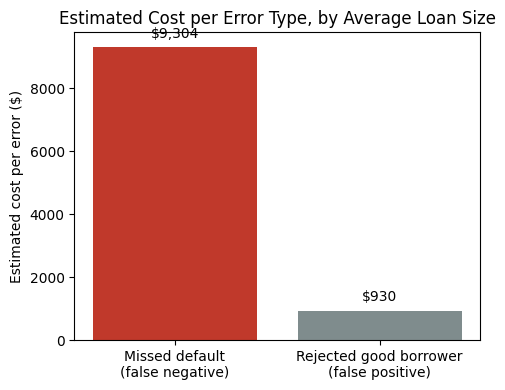

In [ ]:
# Using the dataset's own average loan size to put a number on the two error costs,
# before any model is built. Assumptions: 50% loss-given-default on a missed defaulter
# (reasonable for a collateral-backed home equity loan), 5% forgone interest margin
# on a wrongly rejected good borrower. See Executive Summary for full reasoning.

avg_loan = hm['LOAN'].mean()
cost_missed_default = avg_loan * 0.50
cost_rejected_borrower = avg_loan * 0.05

print(f"Average loan amount: ${avg_loan:,.0f}")
print(f"Estimated cost of missing one defaulter: ${cost_missed_default:,.0f}")
print(f"Estimated cost of wrongly rejecting one good borrower: ${cost_rejected_borrower:,.0f}")
print(f"Ratio: missing a defaulter costs roughly {cost_missed_default/cost_rejected_borrower:.0f}x more")

plt.figure(figsize=(5, 4))
plt.bar(['Missed default\n(false negative)', 'Rejected good borrower\n(false positive)'],
        [cost_missed_default, cost_rejected_borrower],
        color=['#c0392b', '#7f8c8d'])
plt.ylabel('Estimated cost per error ($)')
plt.title('Estimated Cost per Error Type, by Average Loan Size')
for i, v in enumerate([cost_missed_default, cost_rejected_borrower]):
    plt.text(i, v + 300, f'${v:,.0f}', ha='center')
plt.tight_layout()
plt.show()

### **Observation from Cost asymmetry**

Even using conservative assumptions, missing a defaulter costs roughly 10x more than wrongly rejecting a reliable borrower. This asymmetry, not the class imbalance alone, is why recall on the defaulted class will be used as the primary metric for model selection in this project, rather than accuracy or precision.

## Univariate Analysis

### Numerical Variables

#### Histograms

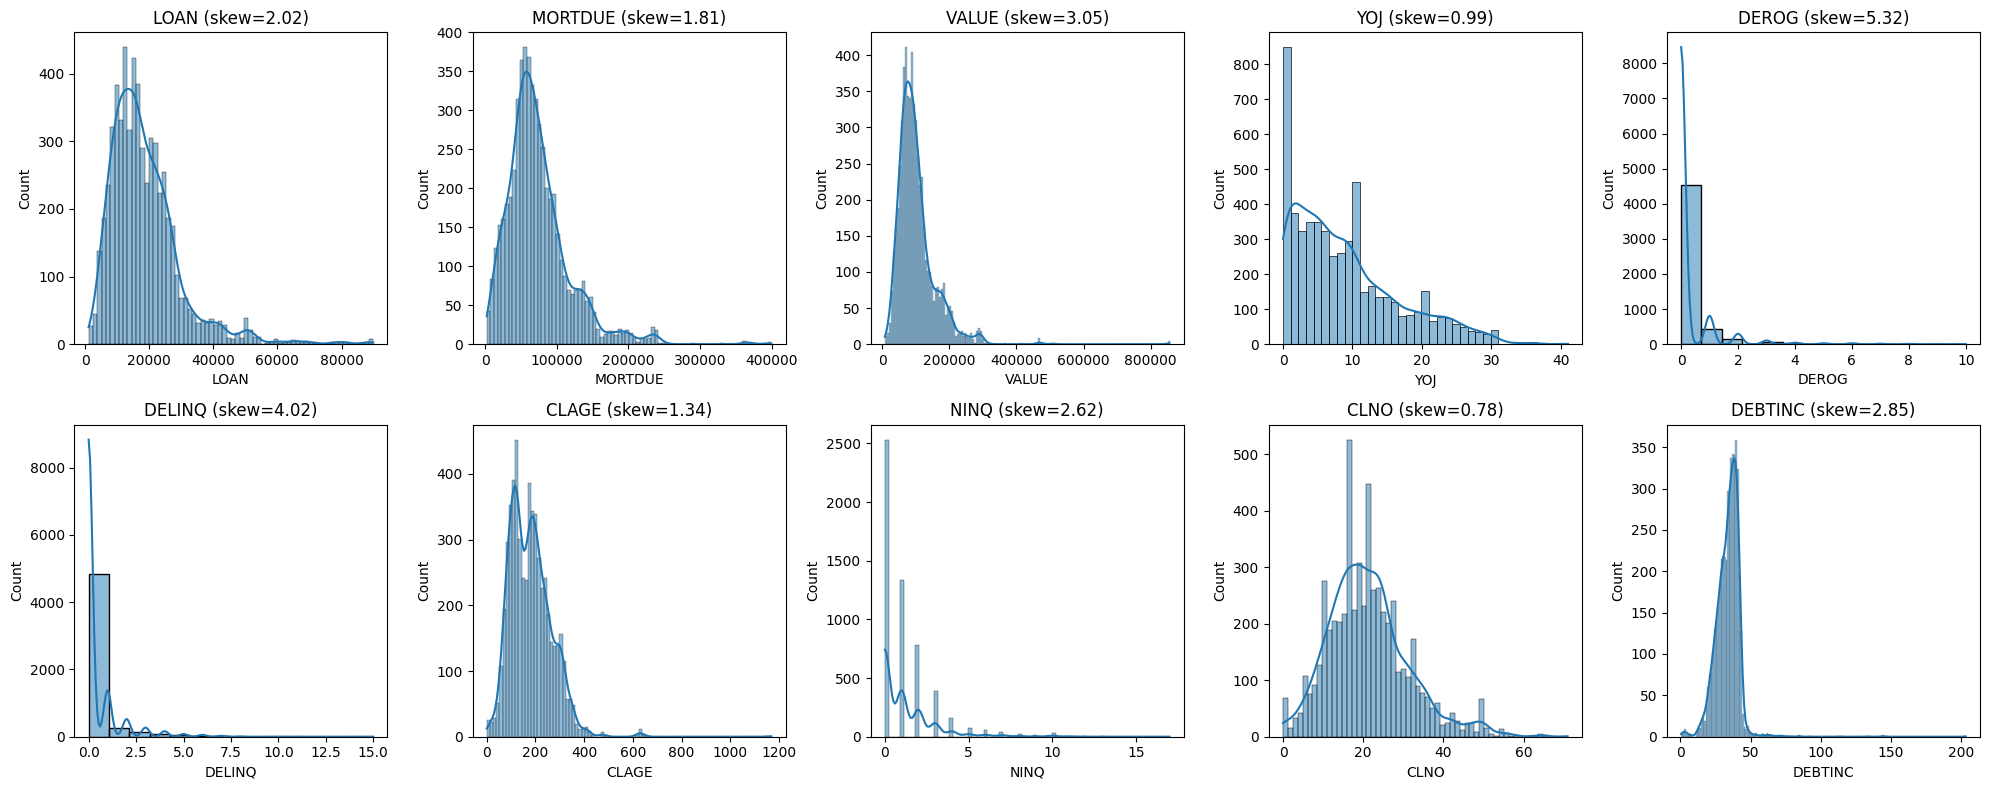

In [ ]:
# Distribution shape and Skewness with Histograms
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_vars):
    skew_val = hm[col].skew()
    sns.histplot(data=hm, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'{col} (skew={skew_val:.2f})')

plt.tight_layout()
plt.show()

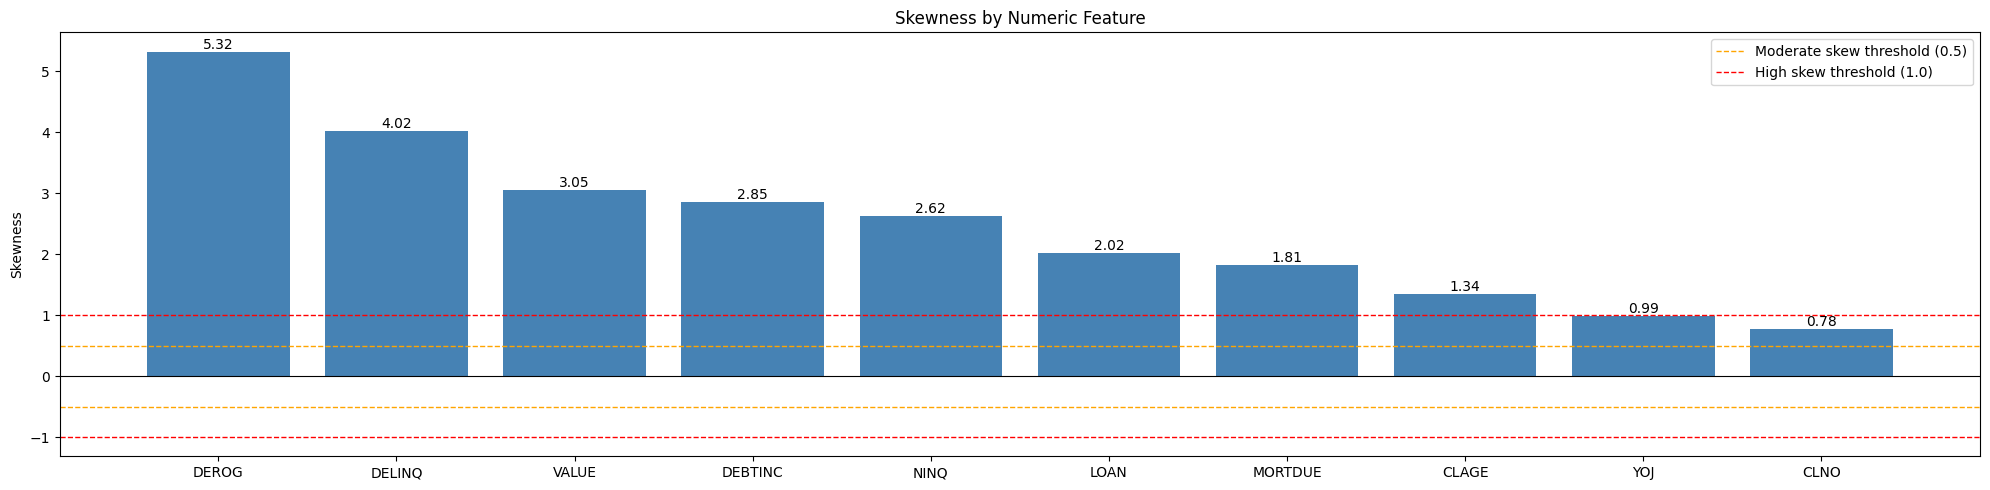

In [ ]:
# Skewness Bar chart
skew_vals = hm[numerical_vars].skew().sort_values(ascending=False)

plt.figure(figsize=(20, 5))
bars = plt.bar(skew_vals.index, skew_vals.values, color='steelblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(0.5, color='orange', linestyle='--', linewidth=1, label='Moderate skew threshold (0.5)')
plt.axhline(1, color='red', linestyle='--', linewidth=1, label='High skew threshold (1.0)')
plt.axhline(-0.5, color='orange', linestyle='--', linewidth=1)
plt.axhline(-1, color='red', linestyle='--', linewidth=1)
plt.bar_label(bars, fmt='%.2f')
plt.title('Skewness by Numeric Feature')
plt.ylabel('Skewness')
plt.legend()
plt.tight_layout()
plt.show()

#### Boxplots

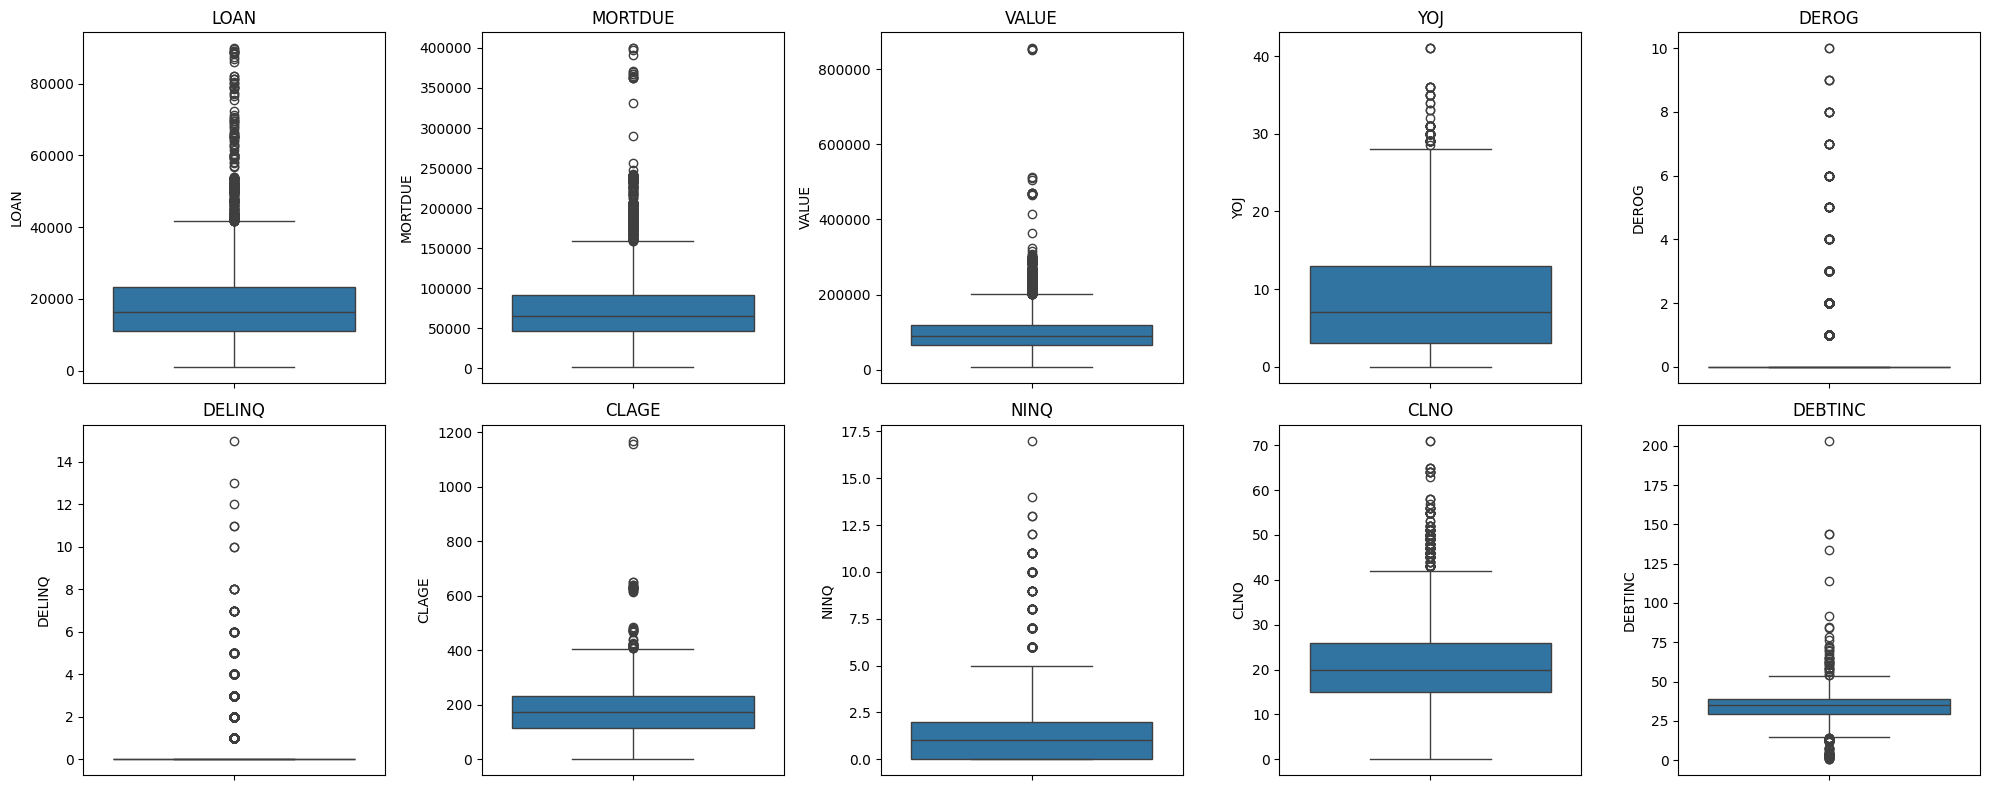

In [ ]:
# Boxplot for visual outlier detection
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_vars):
    sns.boxplot(data=hm, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


### Categorical Variables

#### Frequency counts and bar charts

In [ ]:
categorical_cols = ['REASON', 'JOB']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(hm[col].value_counts())
    print(f"\nPercentage:\n{hm[col].value_counts(normalize=True) * 100}")


--- REASON ---
REASON
DebtCon    3928
HomeImp    1780
Name: count, dtype: int64

Percentage:
REASON
DebtCon    68.815697
HomeImp    31.184303
Name: proportion, dtype: float64

--- JOB ---
JOB
Other      2388
ProfExe    1276
Office      948
Mgr         767
Self        193
Sales       109
Name: count, dtype: int64

Percentage:
JOB
Other      42.034853
ProfExe    22.460834
Office     16.687203
Mgr        13.501144
Self        3.397289
Sales       1.918676
Name: proportion, dtype: float64


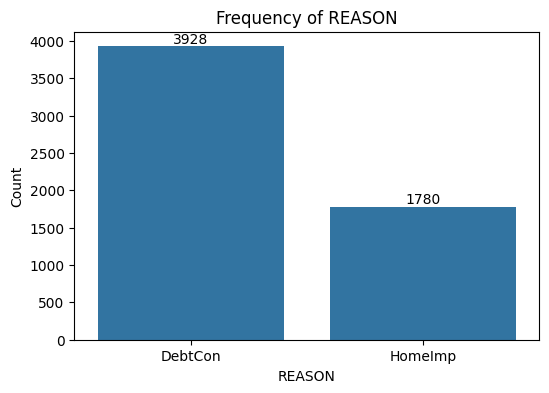

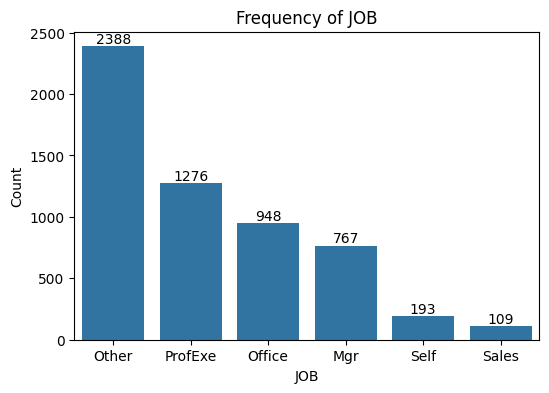

In [ ]:
# Barcharts of Frequency counts
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(data=hm, x=col, order=hm[col].value_counts().index)
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

#### Data Balance

Checking the balance of the target variabe (BAD) as class imbalance between unpaid and defaulted directly affects which metric to optimise for later when dealing with cost assymetry.

In [ ]:
print(hm['BAD'].value_counts())
print(f"\nPercentage:\n{hm['BAD'].value_counts(normalize=True) * 100}")

BAD
0    4771
1    1189
Name: count, dtype: int64

Percentage:
BAD
0    80.050336
1    19.949664
Name: proportion, dtype: float64


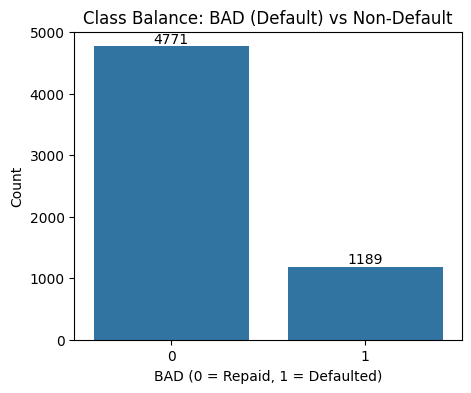

In [ ]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=hm, x='BAD')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Class Balance: BAD (Default) vs Non-Default')
plt.xlabel('BAD (0 = Repaid, 1 = Defaulted)')
plt.ylabel('Count')
plt.show()

## Bivariate Analysis

### Numerical Variables vs target (BAD)

In [ ]:
# Grouped stats of Mean Numerical values vs Target
hm.groupby('BAD')[numerical_vars].mean().T

BAD,0,1
LOAN,19028.107315,16922.119428
MORTDUE,74829.249055,69460.452973
VALUE,102595.921018,98172.846227
YOJ,9.154941,8.027802
DEROG,0.134217,0.707804
DELINQ,0.245133,1.229185
CLAGE,187.002355,150.190183
NINQ,1.032749,1.782765
CLNO,21.317036,21.211268
DEBTINC,33.253129,39.387645


In [ ]:
## Grouped stats of Median Numerical values vs Target
hm.groupby('BAD')[numerical_vars].median().T

BAD,0,1
LOAN,16900.000000,14900.000000
MORTDUE,66839.000000,60279.000000
VALUE,90659.000000,82000.000000
YOJ,7.000000,6.000000
DEROG,0.000000,0.000000
DELINQ,0.000000,0.000000
CLAGE,180.415787,132.866667
NINQ,1.000000,1.000000
CLNO,20.000000,20.000000
DEBTINC,34.541671,38.079762


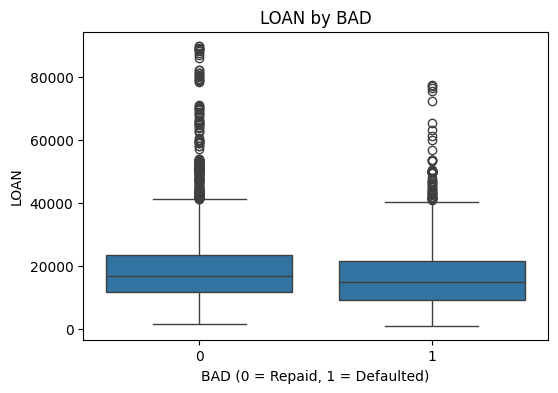

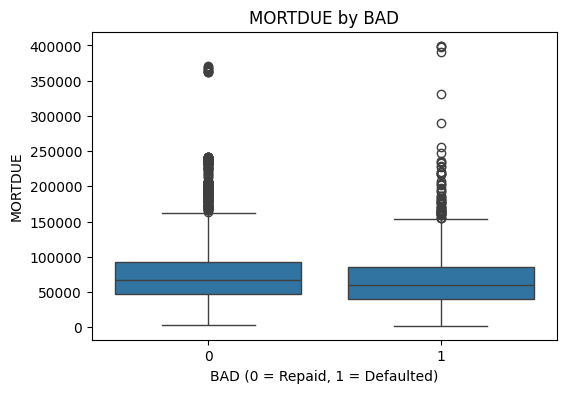

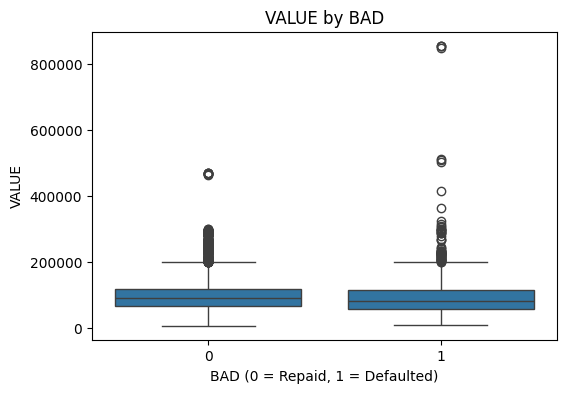

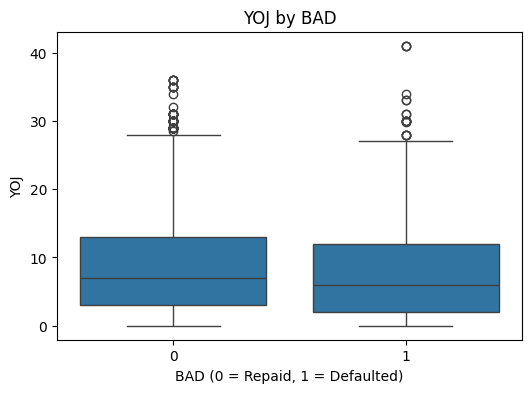

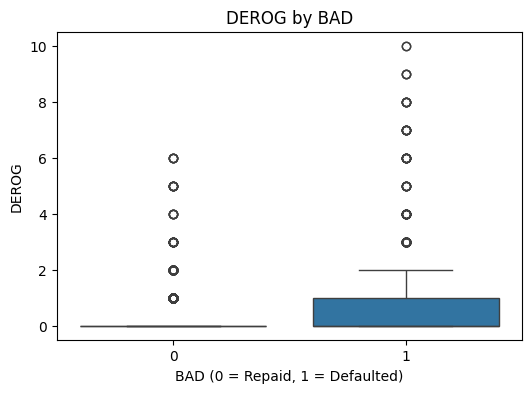

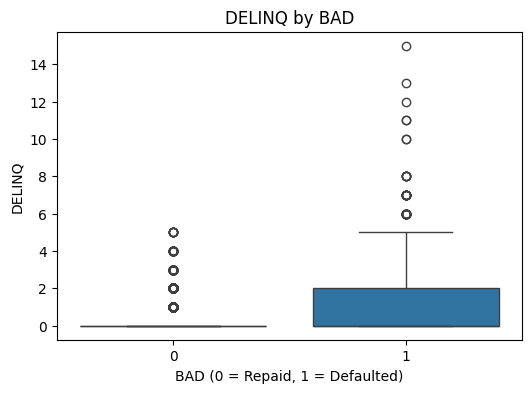

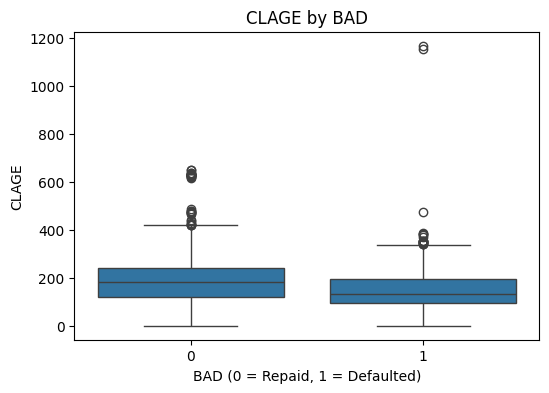

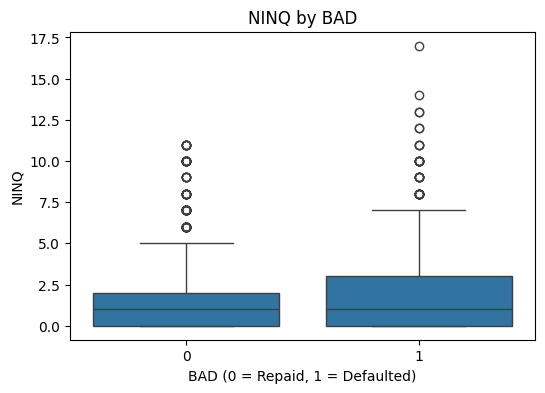

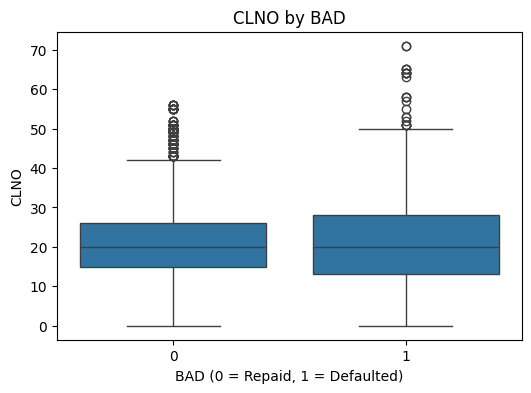

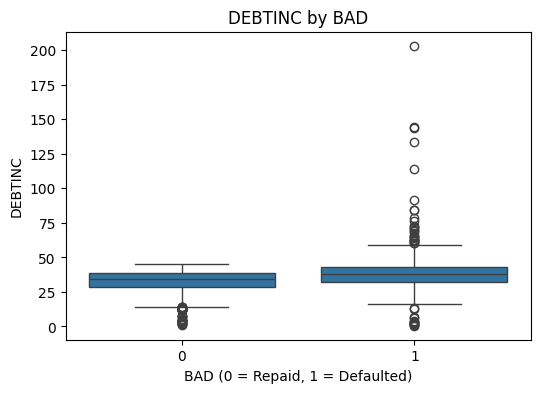

In [ ]:
numeric_cols = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']

for col in numerical_vars:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=hm, x='BAD', y=col)
    plt.title(f'{col} by BAD')
    plt.xlabel('BAD (0 = Repaid, 1 = Defaulted)')
    plt.show()

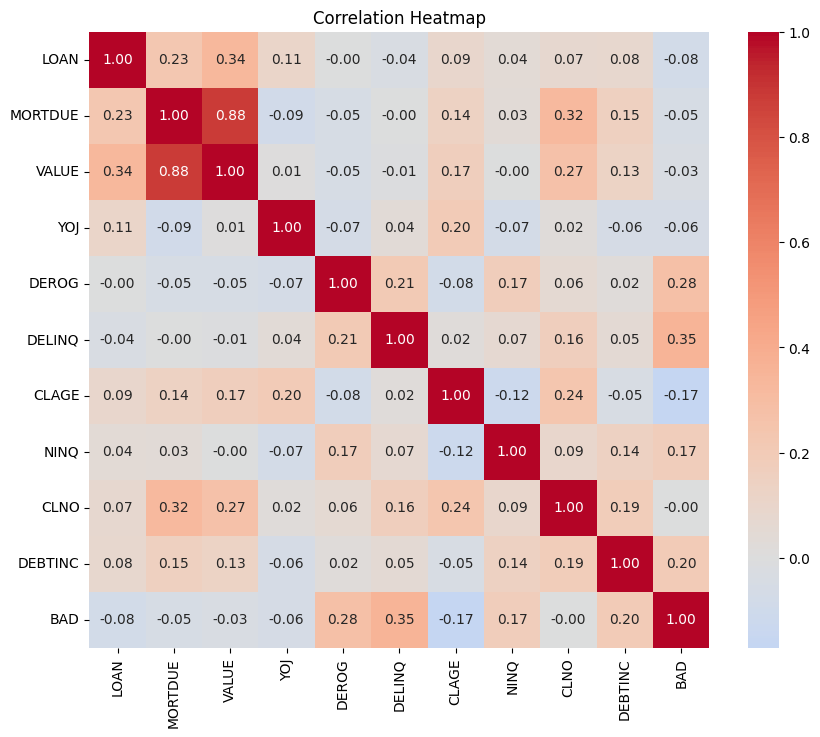

In [ ]:
# Correlation heatmap with Numeric vs Numeric
plt.figure(figsize=(10, 8))
corr = hm[numerical_vars + ['BAD']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

### Categorical Variables vs target (BAD)

In [ ]:
# Default rate by REASON
hm.groupby('REASON')['BAD'].mean()

,BAD
REASON,
DebtCon,0.189664
HomeImp,0.222472


In [ ]:
# Default rate by JOB
hm.groupby('JOB')['BAD'].mean()

,BAD
JOB,
Mgr,0.233377
Office,0.131857
Other,0.231993
ProfExe,0.166144
Sales,0.348624
Self,0.300518


In [ ]:
#  REASON vs JOB
pd.crosstab(hm['REASON'], hm['JOB'], normalize='index') * 100

JOB,Mgr,Office,Other,ProfExe,Sales,Self
REASON,,,,,,
DebtCon,15.001311,16.260163,42.066614,22.213480,2.543929,1.914503
HomeImp,10.098665,17.469530,41.555427,23.505514,0.696460,6.674405


In [ ]:

# Crosstab with counts too
pd.crosstab(hm['REASON'], hm['BAD'], normalize='index')

BAD,0,1
REASON,,
DebtCon,0.810336,0.189664
HomeImp,0.777528,0.222472


In [ ]:
# Frequency count for categorical variables "REASON" and "JOB"
categorical_cols = ['REASON', 'JOB']

for col in categorical_cols:
    print(f"\n--- {col} vs BAD ---")
    print(hm.groupby(col)['BAD'].agg(['mean', 'count']))


--- REASON vs BAD ---
             mean  count
REASON                  
DebtCon  0.189664   3928
HomeImp  0.222472   1780

--- JOB vs BAD ---
             mean  count
JOB                     
Mgr      0.233377    767
Office   0.131857    948
Other    0.231993   2388
ProfExe  0.166144   1276
Sales    0.348624    109
Self     0.300518    193


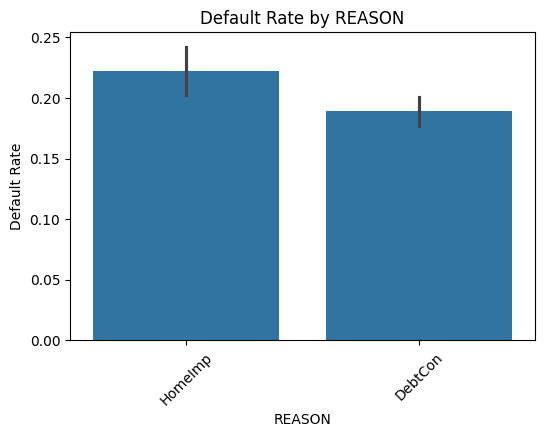

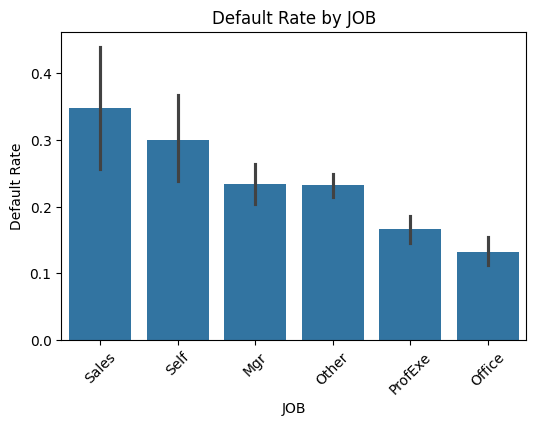

In [ ]:
# Barplot showing the Frequency and standard deviation
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=hm, x=col, y='BAD', order=hm.groupby(col)['BAD'].mean().sort_values(ascending=False).index)
    plt.title(f'Default Rate by {col}')
    plt.ylabel('Default Rate')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Correlation of each numeric variable specifically with BAD
corr_with_target = hm[numeric_cols + ['BAD']].corr()['BAD'].drop('BAD').sort_values(ascending=False)
corr_with_target

,BAD
DELINQ,0.354107
DEROG,0.276081
DEBTINC,0.199835
NINQ,0.174980
CLNO,-0.004157
VALUE,-0.029954
MORTDUE,-0.048219
YOJ,-0.060238
LOAN,-0.075099
CLAGE,-0.170499


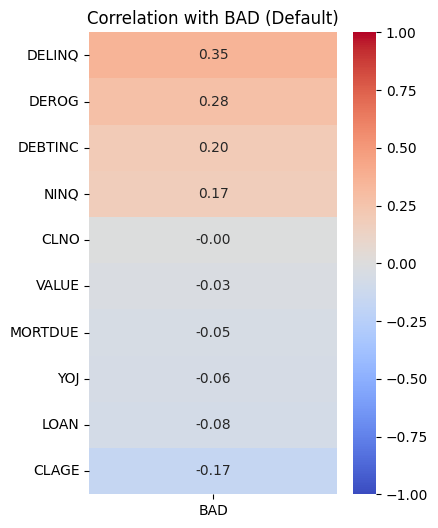

In [ ]:
# Correlation of each numeric variable specifically with BAD using heatmap
numeric_cols = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']

corr_with_target = hm[numeric_cols + ['BAD']].corr()[['BAD']].drop('BAD')
corr_with_target = corr_with_target.sort_values(by='BAD', ascending=False)

plt.figure(figsize=(4, 6))
sns.heatmap(corr_with_target, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation with BAD (Default)')
plt.show()

## Multivariate Analysis

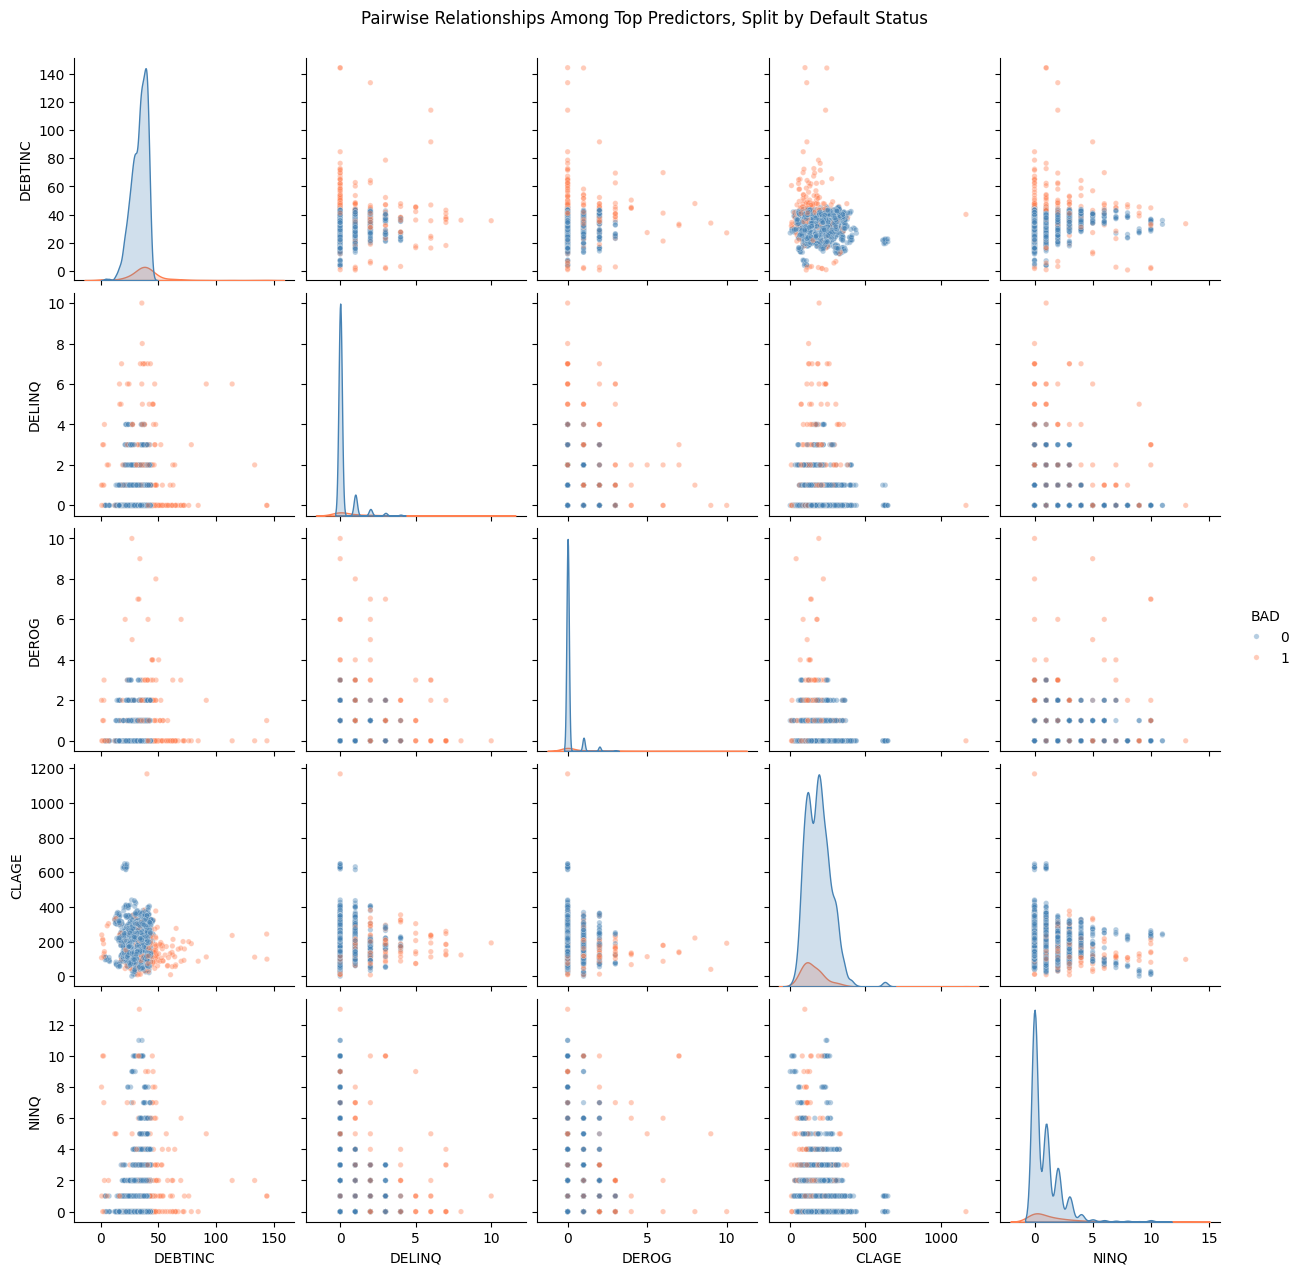

In [ ]:
# Multivariate view: joint distributions of the strongest predictors, split by BAD
top_features = ['DEBTINC', 'DELINQ', 'DEROG', 'CLAGE', 'NINQ']

sns.pairplot(
    hm[top_features + ['BAD']].dropna(),
    hue='BAD',
    palette={0: 'steelblue', 1: 'coral'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15}
)
plt.suptitle('Pairwise Relationships Among Top Predictors, Split by Default Status', y=1.02)
plt.show()

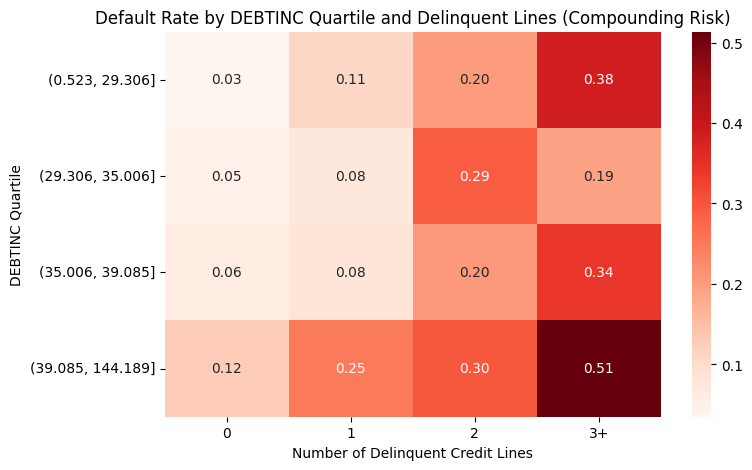

In [ ]:
# Does high DEBTINC combined with high DELINQ compound risk beyond either alone?
hm_temp = hm.dropna(subset=['DEBTINC', 'DELINQ']).copy()
hm_temp['DEBTINC_bin'] = pd.qcut(hm_temp['DEBTINC'], q=4, duplicates='drop')
hm_temp['DELINQ_bin'] = pd.cut(hm_temp['DELINQ'], bins=[-1, 0, 1, 2, hm_temp['DELINQ'].max()],
                                 labels=['0', '1', '2', '3+'])

interaction = hm_temp.groupby(['DEBTINC_bin', 'DELINQ_bin'], observed=True)['BAD'].mean().unstack()

plt.figure(figsize=(8, 5))
sns.heatmap(interaction, annot=True, fmt='.2f', cmap='Reds')
plt.title('Default Rate by DEBTINC Quartile and Delinquent Lines (Compounding Risk)')
plt.xlabel('Number of Delinquent Credit Lines')
plt.ylabel('DEBTINC Quartile')
plt.show()

## **Observations & Insights from EDA**

**Univariate Analysis**
- The target variable is imbalanced: 80.1% of applicants repaid, 19.9% defaulted, which rules out accuracy as a standalone metric and supports the recall-weighted approach in the problem formulation.
****

**Bivariate Analysis**
- Bivariate analysis shows defaulters carry higher DELINQ (1.23 vs. 0.25), DEROG (0.71 vs. 0.13), NINQ (1.78 vs. 1.03), and DEBTINC (39.4 vs. 33.3) than non-defaulters, while CLAGE is lower for defaulters (150.2 vs. 187.0 months), meaning shorter credit history tracks with higher risk.
- Correlation with BAD confirms the same ranking: DELINQ (0.354), DEROG (0.276), DEBTINC (0.200), and NINQ (0.175) are the strongest linear signals, while LOAN, MORTDUE, VALUE, and CLNO show near-zero or weak negative correlation: property and loan size matter far less than repayment behavior.
- Categorically, Sales (34.9%) and Self-employed (30.1%) applicants default at roughly double the rate of Office (13.2%) and ProfExe (16.6%) applicants, and DebtCon loans default slightly less often than HomeImp loans (18.9% vs. 22.2%).
- The chi-square test confirms seven of eight numeric variables have informative missingness (p < 0.05): VALUE, DEBTINC, CLAGE, NINQ, YOJ, DELINQ, and DEROG. Only MORTDUE's missingness is unrelated to default risk (p = 0.80). All seven significant flags are retained as model features.
- VALUE shows the single largest rate gap in the dataset: applicants missing this field default at 93.8%, against 18.5% for those who report it, a 75.2-point gap that exceeds even DEBTINC's.
- The single strongest finding by correlation strength remains DEBTINC's missingness pattern: applicants missing this field default at 62.0%, against 8.6% for those who report it, a signal stronger than any variable's raw correlation coefficient, which is why it was preserved as a _missing indicator feature rather than imputed away.
****
**Multivariate Analysis**
- Delinquency compounds risk at every debt-to-income level, not just high ones. Even in the safest DEBTINC quartile (0.5–30.8), default rate jumps from 3% at zero delinquent lines to 39% at 3+, a roughly 13x increase. The relative jump is actually largest in this lowest-DEBTINC group, meaning DEBTINC alone would badly understate risk for an applicant who looks financially safe on paper but has a delinquency history. This is the clearest evidence in the notebook that DELINQ carries independent signal rather than being a proxy for what DEBTINC already captures.

- DEBTINC's relationship with default is not monotonic in the raw data, even though the final model enforces it to be. The (30.8, 34.8] quartile shows default rates of 29–84% across DELINQ levels, higher than both the quartile below it and, more strikingly, the quartile above it (37.95–203, capturing much larger debt burdens), where rates only reach 11–49%. Applicants with the highest recorded DEBTINC are not the highest-risk group in this data. That's worth naming explicitly, because it means the monotonic constraint applied later (DEBTINC risk can only increase, never decrease) is a modeling choice made for ECOA defensibility, not a pattern that already existed cleanly in the data. Worth a sentence acknowledging that trade-off directly: interpretability required smoothing over a real, if puzzling, empirical dip. This could be a real threshold effect in how the original human underwriters made cutoffs, or a small-sample artifact in that narrow band; either way it's worth flagging rather than glossing over, since it goes to the same "does the model learn the bank's inconsistent judgment calls" concern raised in the problem statement.

- No single pair of these five top predictors cleanly separates defaulters from repayers. The pairplot shows heavy overlap between BAD=0 and BAD=1 in every 2D scatter panel. Only the univariate distributions (diagonal) show any separation, CLAGE skews shorter and DEBTINC skews slightly bimodal for defaulters, but even those overlap substantially. This confirms the classification signal is spread across many weak, interacting features rather than concentrated in one or two strong ones, which is the empirical case for why tree-based ensembles (which combine many such interactions) outperformed the single-variable logic a simple heuristic or linear model would rely on.

- The handful of extreme DEBTINC values (>100) visible in the pairplot scatter panels belong almost entirely to defaulters, consistent with your earlier decision to retain rather than cap these as an outlier-flag feature; they look like genuine high-risk cases, not data errors.

## Data Preprocessing

### Treating Outliers

In [ ]:
# Outlier treatment in the upper and lower bounds
def detect_outliers_iqr(df, cols):
    results = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        results.append({
            'Column': col,
            'Lower Bound': round(lower, 2),
            'Upper Bound': round(upper, 2),
            'Outlier Count': ((df[col] < lower) | (df[col] > upper)).sum()
        })
    return pd.DataFrame(results)

outlier_summary = detect_outliers_iqr(hm, numeric_cols)
outlier_summary

,Column,Lower Bound,Upper Bound,Outlier Count
0,LOAN,-7200.00,41600.00,256
1,MORTDUE,-21542.00,159306.00,234
2,VALUE,-14547.62,200447.38,320
3,YOJ,-12.00,28.00,91
4,DEROG,0.00,0.00,725
5,DELINQ,0.00,0.00,1201
6,CLAGE,-59.55,406.23,47
7,NINQ,-3.00,5.00,177
8,CLNO,-1.50,42.50,219
9,DEBTINC,14.35,53.80,94


In [ ]:
# Flagging outliers as a feature rather than remove/cap them,
# since extreme DEBTINC/DELINQ/DEROG values are plausible high-risk cases,
# not data errors and removing them would discard the applicants the model most needs to identify.
for col in ['DEBTINC', 'DELINQ', 'DEROG']:
    Q1 = hm[col].quantile(0.25)
    Q3 = hm[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    hm[f'{col}_outlier'] = (hm[col] > upper).astype(int)

## Treating Missing Values

### Significant Missing Values associated with BAD >5%








In [ ]:
from scipy.stats import chi2_contingency

missing_cols = ['MORTDUE', 'VALUE', 'DEROG', 'DELINQ', 'YOJ', 'NINQ', 'CLAGE', 'DEBTINC']

results = []

for col in missing_cols:
    missing_flag = f'{col}_missing'
    hm[missing_flag] = hm[col].isnull().astype(int)

    # Skip columns with no missing values -- chi-square needs both groups present
    if hm[missing_flag].nunique() < 2:
        results.append({
            'Column': col,
            'Missing Count': 0,
            'Missing %': 0.0,
            'Default Rate (Present)': None,
            'Default Rate (Missing)': None,
            'Rate Gap (pts)': None,
            'p-value': None,
            'Significant?': 'No missing values'
        })
        continue

    summary = hm.groupby(missing_flag)['BAD'].agg(['mean', 'count'])
    rate_present = summary.loc[0, 'mean']
    rate_missing = summary.loc[1, 'mean']
    count_missing = summary.loc[1, 'count']

    ct = pd.crosstab(hm[missing_flag], hm['BAD'])
    chi2, p, dof, expected = chi2_contingency(ct)

    results.append({
        'Column': col,
        'Missing Count': count_missing,
        'Missing %': round(count_missing / len(hm) * 100, 1),
        'Default Rate (Present)': round(rate_present * 100, 1),
        'Default Rate (Missing)': round(rate_missing * 100, 1),
        'Rate Gap (pts)': round((rate_missing - rate_present) * 100, 1),
        'p-value': round(p, 4),
        'Significant?': 'Yes' if p < 0.05 else 'No'
    })

missing_summary = pd.DataFrame(results).sort_values('Rate Gap (pts)', ascending=False, na_position='last')
missing_summary

,Column,Missing Count,Missing %,Default Rate (Present),Default Rate (Missing),Rate Gap (pts),p-value,Significant?
1,VALUE,112,1.9,18.5,93.8,75.2,0.0000,Yes
7,DEBTINC,1267,21.3,8.6,62.0,53.4,0.0000,Yes
6,CLAGE,308,5.2,19.7,25.3,5.7,0.0187,Yes
0,MORTDUE,518,8.7,19.9,20.5,0.6,0.8037,No
5,NINQ,510,8.6,20.4,14.7,-5.7,0.0024,Yes
4,YOJ,515,8.6,20.6,12.6,-8.0,0.0000,Yes
3,DELINQ,580,9.7,20.8,12.4,-8.3,0.0000,Yes
2,DEROG,708,11.9,21.0,12.3,-8.7,0.0000,Yes


In [ ]:
# Deriving informative columns directly from the significance test above, rather than hand-picking,
# so the feature set matches the test results exactly with no manual judgment call involved.
informative_missing_cols = missing_summary[missing_summary['Significant?'] == 'Yes']['Column'].tolist()
print("Informative missingness columns (p < 0.05):", informative_missing_cols)

for col in informative_missing_cols:
    hm[f'{col}_missing'] = hm[col].isnull().astype(int)

Informative missingness columns (p < 0.05): ['VALUE', 'DEBTINC', 'CLAGE', 'NINQ', 'YOJ', 'DELINQ', 'DEROG']


In [ ]:
# Cells above created a _missing flag for all 8 columns tested for significance;
# only MORTDUE failed the test (p = 0.80), so its flag is dropped, keeping the other seven.
non_informative_missing_cols = missing_summary[missing_summary['Significant?'] != 'Yes']['Column'].tolist()
hm = hm.drop(columns=[f'{col}_missing' for col in non_informative_missing_cols], errors='ignore')

print("Remaining missingness flags:", [c for c in hm.columns if c.endswith('_missing')])

Remaining missingness flags: ['VALUE_missing', 'DEROG_missing', 'DELINQ_missing', 'YOJ_missing', 'NINQ_missing', 'CLAGE_missing', 'DEBTINC_missing']


In [ ]:
# Numeric columns: impute with median (robust to skew, per skewness findings)
numeric_impute_cols = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']

for col in numeric_impute_cols:
    median_val = hm[col].median()
    hm[col] = hm[col].fillna(median_val)

# Categorical columns: impute with mode
categorical_impute_cols = ['REASON', 'JOB']

for col in categorical_impute_cols:
    mode_val = hm[col].mode()[0]
    hm[col] = hm[col].fillna(mode_val)

# Verify no missing values remain
print(hm.isnull().sum().sum(), "missing values remaining")

0 missing values remaining


In [ ]:
# Default rate by JOB and REASON combined
hm.groupby(['JOB', 'REASON'])['BAD'].agg(['mean', 'count']).round(3)

mean  count
JOB     REASON               
Mgr     DebtCon  0.207    593
        HomeImp  0.322    174
Office  DebtCon  0.142    647
        HomeImp  0.110    301
Other   DebtCon  0.194   1894
        HomeImp  0.270    773
ProfExe DebtCon  0.160    871
        HomeImp  0.180    405
Sales   DebtCon  0.351     97
        HomeImp  0.333     12
Self    DebtCon  0.474     78
        HomeImp  0.183    115

In [ ]:
# Default rate by JOB, split by whether DEBTINC was missing
hm.groupby(['JOB', 'DEBTINC_missing'])['BAD'].mean().unstack().round(3)

DEBTINC_missing,0,1
JOB,,
Mgr,0.097,0.674
Office,0.061,0.484
Other,0.093,0.648
ProfExe,0.069,0.560
Sales,0.203,0.733
Self,0.134,0.765


In [ ]:
# One-hot encode REASON and JOB
hm_encoded = pd.get_dummies(hm, columns=['REASON', 'JOB'], drop_first=True, dtype=int)

hm_encoded.head()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,YOJ_missing,NINQ_missing,CLAGE_missing,DEBTINC_missing,REASON_HomeImp,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,...,0,0,0,1,1,0,1,0,0,0
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,...,0,0,0,1,1,0,1,0,0,0
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,...,0,0,0,1,1,0,1,0,0,0
3,1,1500,65019.0,89235.5,7.0,0.0,0.0,173.466667,1.0,20.0,...,1,1,1,1,0,0,1,0,0,0
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,...,0,0,0,1,1,1,0,0,0,0


In [ ]:
# Sanity check to confirm all columns are now numeric and model-ready
print(hm_encoded.dtypes.value_counts())
print(f"\nShape after encoding: {hm_encoded.shape}")

int64      18
float64     9
Name: count, dtype: int64

Shape after encoding: (5960, 27)


#**5. Model Building**

## Data preparation


In [ ]:
# Separate features and target
X = hm_encoded.drop(columns=['BAD'])
y = hm_encoded['BAD']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Features shape: (5960, 26)
Target distribution:
BAD
0    0.800503
1    0.199497
Name: proportion, dtype: float64


### Partitioning the data into train and test sets


In [ ]:
# stratify=y keeps the ~80/20 class split consistent in both train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True)}")

Train shape: (4172, 26), Test shape: (1788, 26)

Train target distribution:
BAD
0    0.800575
1    0.199425
Name: proportion, dtype: float64

Test target distribution:
BAD
0    0.800336
1    0.199664
Name: proportion, dtype: float64


### Shared evaluation function

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix, classification_report)

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    print(f"=== {model_name} ===")
    print("\nTest Set Performance:")
    print(classification_report(y_test, y_test_pred, target_names=['Repaid', 'Defaulted']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.3f}")

    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Repaid', 'Defaulted'], yticklabels=['Repaid', 'Defaulted'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return {
        'Model': model_name,
        'Train Accuracy': round(accuracy_score(y_train, y_train_pred), 3),
        'Test Accuracy': round(accuracy_score(y_test, y_test_pred), 3),
        'Precision (Default)': round(precision_score(y_test, y_test_pred), 3),
        'Recall (Default)': round(recall_score(y_test, y_test_pred), 3),
        'F1 (Default)': round(f1_score(y_test, y_test_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_test_proba), 3)
    }

model_results = []


## **Logistic Regression**

### Building, fitting the model


In [ ]:
from sklearn.linear_model import LogisticRegression

# Build and fit
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

=== Logistic Regression ===

Test Set Performance:
              precision    recall  f1-score   support

      Repaid       0.92      0.83      0.87      1431
   Defaulted       0.51      0.69      0.59       357

    accuracy                           0.81      1788
   macro avg       0.71      0.76      0.73      1788
weighted avg       0.84      0.81      0.82      1788

ROC-AUC: 0.838


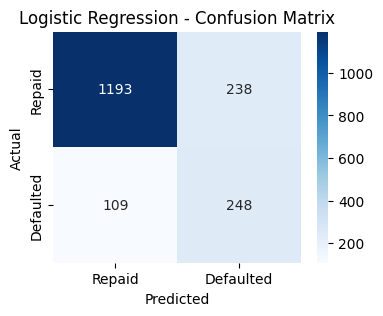

In [ ]:
# Testing
model_results.append(evaluate_model(log_reg, X_train, X_test, y_train, y_test, "Logistic Regression"))

In [ ]:
# Interpretability: coefficients show direction and magnitude of each feature's effect
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

coef_df

,Feature,Coefficient
5,DELINQ,1.064000
19,DEBTINC_missing,1.050257
4,DEROG,0.640369
11,DELINQ_outlier,0.338683
12,DEROG_outlier,0.269633
13,VALUE_missing,0.191240
18,CLAGE_missing,0.110223
20,REASON_HomeImp,0.065518
24,JOB_Sales,0.058949
25,JOB_Self,0.052741


## **Decision Tree**

=== Decision Tree (default) ===

Test Set Performance:
              precision    recall  f1-score   support

      Repaid       0.90      0.94      0.92      1431
   Defaulted       0.70      0.59      0.64       357

    accuracy                           0.87      1788
   macro avg       0.80      0.76      0.78      1788
weighted avg       0.86      0.87      0.86      1788

ROC-AUC: 0.764


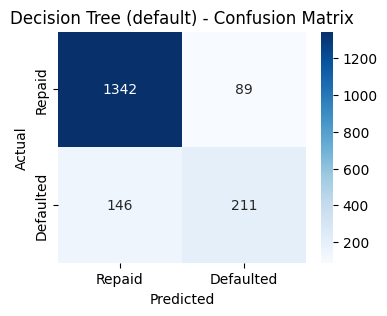

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

model_results.append(evaluate_model(dt, X_train, X_test, y_train, y_test, "Decision Tree (default)"))

### Hyperparameter Tuning

Best params: {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
=== Decision Tree (tuned) ===

Test Set Performance:
              precision    recall  f1-score   support

      Repaid       0.93      0.82      0.87      1431
   Defaulted       0.51      0.76      0.61       357

    accuracy                           0.81      1788
   macro avg       0.72      0.79      0.74      1788
weighted avg       0.85      0.81      0.82      1788

ROC-AUC: 0.853


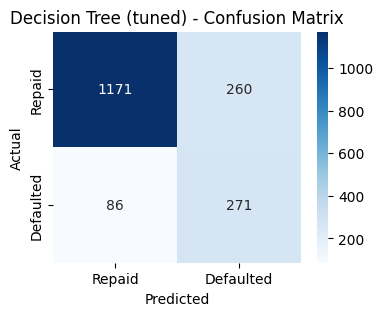

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid, cv=5, scoring='recall', n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print("Best params:", dt_grid.best_params_)
dt_tuned = dt_grid.best_estimator_

model_results.append(evaluate_model(dt_tuned, X_train, X_test, y_train, y_test, "Decision Tree (tuned)"))

In [ ]:
# Interpretability: feature importances
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

dt_importance.head(10)

,Feature,Importance
19,DEBTINC_missing,0.452720
9,DEBTINC,0.157048
6,CLAGE,0.062891
8,CLNO,0.060211
5,DELINQ,0.051098
2,VALUE,0.045904
0,LOAN,0.038676
1,MORTDUE,0.029949
3,YOJ,0.025388
7,NINQ,0.018920


## **Random Forest**

=== Random Forest ===

Test Set Performance:
              precision    recall  f1-score   support

      Repaid       0.94      0.94      0.94      1431
   Defaulted       0.74      0.74      0.74       357

    accuracy                           0.90      1788
   macro avg       0.84      0.84      0.84      1788
weighted avg       0.90      0.90      0.90      1788

ROC-AUC: 0.940


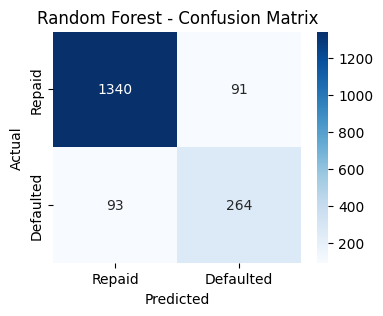

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42,
    class_weight='balanced', n_jobs=-1
)
rf.fit(X_train, y_train)

model_results.append(evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest"))

In [ ]:
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

rf_importance.head(10)

,Feature,Importance
19,DEBTINC_missing,0.254550
9,DEBTINC,0.178867
6,CLAGE,0.080914
5,DELINQ,0.064370
0,LOAN,0.048712
2,VALUE,0.048342
11,DELINQ_outlier,0.043127
8,CLNO,0.043107
1,MORTDUE,0.042317
3,YOJ,0.031996


## **XGBoost**

In [ ]:
# Confirming feauture matrix is ready to reuse
print(X_train.columns.tolist())

['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'DEBTINC_outlier', 'DELINQ_outlier', 'DEROG_outlier', 'VALUE_missing', 'DEROG_missing', 'DELINQ_missing', 'YOJ_missing', 'NINQ_missing', 'CLAGE_missing', 'DEBTINC_missing', 'REASON_HomeImp', 'JOB_Office', 'JOB_Other', 'JOB_ProfExe', 'JOB_Sales', 'JOB_Self']


In [ ]:
# Dictionary of monotonic constraints
monotone_map = {
    'DEBTINC': 1,   # higher debt-to-income -> higher default risk
    'DELINQ': 1,    # more delinquent lines -> higher risk
    'DEROG': 1,      # more derogatory reports -> higher risk
    'NINQ': 1,        # more recent inquiries -> higher risk
    'CLAGE': -1,      # older credit history -> lower risk
    'VALUE': -1,      # higher property value -> lower risk
}
constraints = tuple(monotone_map.get(c, 0) for c in X_train.columns)
# Everything not in the dictionary gets 0 automatically (no constraint).
# That is why the dictionary lookup uses .get(c, 0)

### Fitting and training the model

In [ ]:
xgb_clf = xgb. XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    monotone_constraints=constraints,
    scale_pos_weight=(y_train == 0). sum() / (y_train == 1). sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)


xgb_clf.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan,
              monotone_constraints=(0, 0, -1, 0, 1, 1, -1, 1, 0, 1, 0, 0, 0, 0,
                                    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0),
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

### Testing

=== XGBoost (Monotonic) ===

Test Set Performance:
              precision    recall  f1-score   support

      Repaid       0.95      0.91      0.93      1431
   Defaulted       0.70      0.82      0.76       357

    accuracy                           0.89      1788
   macro avg       0.83      0.87      0.85      1788
weighted avg       0.90      0.89      0.90      1788

ROC-AUC: 0.943


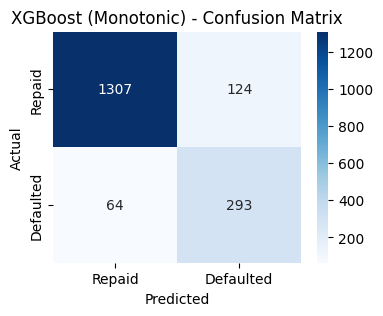

In [ ]:
model_results.append(evaluate_model(xgb_clf, X_train, X_test, y_train, y_test, "XGBoost (Monotonic)"))

### SHAP for XGBoost

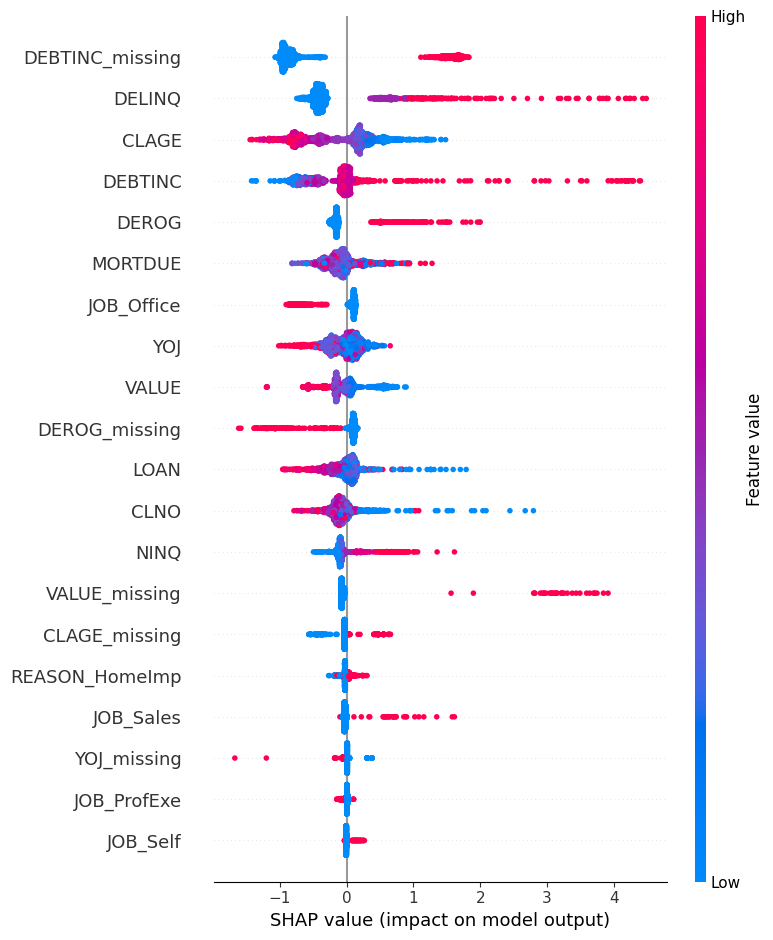

In [ ]:
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)

In [ ]:
# How much does XGBoost's actual decision-making rely on JOB, the closest available proxy variable?
# Reuses shap_values already computed so no need to refit or re-explain.

job_cols = [c for c in X_test.columns if c.startswith('JOB_')]
reason_cols = [c for c in X_test.columns if c.startswith('REASON_')]

# shap.TreeExplainer on a binary XGBClassifier returns either a single (n_samples, n_features)
# array for the positive class, or a list [class0, class1] depending on the shap version.
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

mean_abs_shap = pd.Series(
    np.abs(sv).mean(axis=0), index=X_test.columns
).sort_values(ascending=False)

total_signal = mean_abs_shap.sum()
job_signal = mean_abs_shap[job_cols].sum()
reason_signal = mean_abs_shap[reason_cols].sum()

print(f"JOB dummy variables account for {job_signal / total_signal:.1%} of total mean |SHAP| across all features")
print(f"REASON dummy variables account for {reason_signal / total_signal:.1%} of total mean |SHAP|\n")

job_rank = mean_abs_shap.rank(ascending=False)
print("Where each JOB dummy ranks among all features, by mean |SHAP|:")
print(job_rank[job_cols].astype(int).sort_values())

print(f"\nTotal number of features: {len(mean_abs_shap)}")
mean_abs_shap.head(10)

JOB dummy variables account for 5.9% of total mean |SHAP| across all features
REASON dummy variables account for 0.9% of total mean |SHAP|

Where each JOB dummy ranks among all features, by mean |SHAP|:
JOB_Office      7
JOB_Sales      17
JOB_ProfExe    19
JOB_Self       20
JOB_Other      21
dtype: int64

Total number of features: 26


,0
DEBTINC_missing,1.028440
DELINQ,0.556621
CLAGE,0.466685
DEBTINC,0.366165
DEROG,0.232769
MORTDUE,0.194202
JOB_Office,0.193834
YOJ,0.184298
VALUE,0.183525
DEROG_missing,0.183373


## **Explainable Boosting Machine (EBM)**

### Installing and Importing

In [ ]:
# Installing
!pip install interpret --break-system-packages

In [ ]:
# Importing
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
# Sanity check for comparable train/test data from XGBoost
print(X_train.shape, X_test.shape)
print(X_train.isnull().sum().sum(), X_test.isnull().sum().sum())
print(X_train.columns.tolist())

(4172, 26) (1788, 26)
0 0
['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'DEBTINC_outlier', 'DELINQ_outlier', 'DEROG_outlier', 'VALUE_missing', 'DEROG_missing', 'DELINQ_missing', 'YOJ_missing', 'NINQ_missing', 'CLAGE_missing', 'DEBTINC_missing', 'REASON_HomeImp', 'JOB_Office', 'JOB_Other', 'JOB_ProfExe', 'JOB_Sales', 'JOB_Self']


### Fitting EBM with class imbalance and monotonic constraints

In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Reusing the same monotonic constraints defined for XGBoost
# same domain logic should apply regardless of which model enforces it
ebm_clf = ExplainableBoostingClassifier(random_state=1, monotone_constraints=list(constraints))
ebm_clf.fit(X_train, y_train, sample_weight=sample_weights)

ExplainableBoostingClassifier(monotone_constraints=[0, 0, -1, 0, 1, 1, -1, 1, 0,
                                                    1, 0, 0, 0, 0, 0, 0, 0, 0,
                                                    0, 0, 0, 0, 0, 0, 0, 0],
                              random_state=1)

### Testing

=== EBM (Monotonic) ===

Test Set Performance:
              precision    recall  f1-score   support

      Repaid       0.95      0.91      0.93      1431
   Defaulted       0.69      0.82      0.75       357

    accuracy                           0.89      1788
   macro avg       0.82      0.86      0.84      1788
weighted avg       0.90      0.89      0.89      1788

ROC-AUC: 0.945


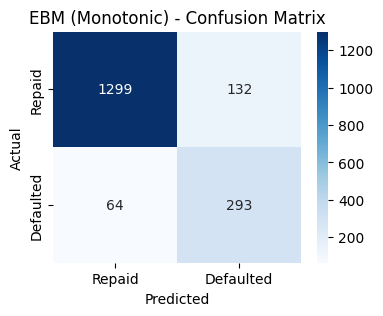

In [ ]:
model_results.append(evaluate_model(ebm_clf, X_train, X_test, y_train, y_test, "EBM (Monotonic)"))

### Interpretability output

In [ ]:
ebm_global = ebm_clf.explain_global()

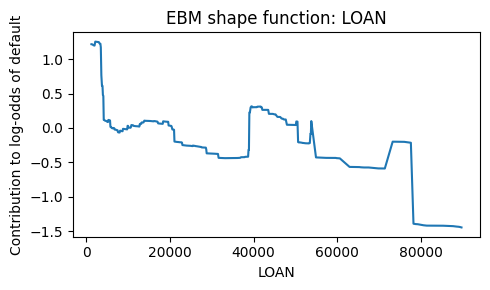

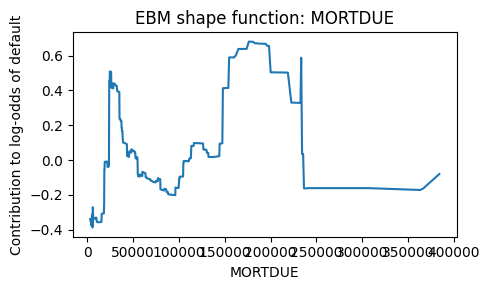

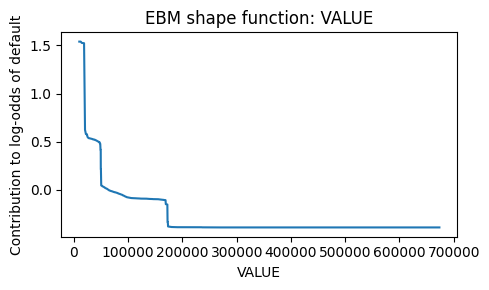

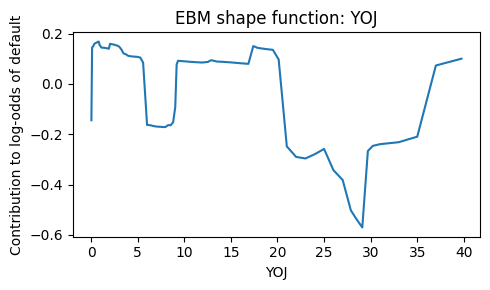

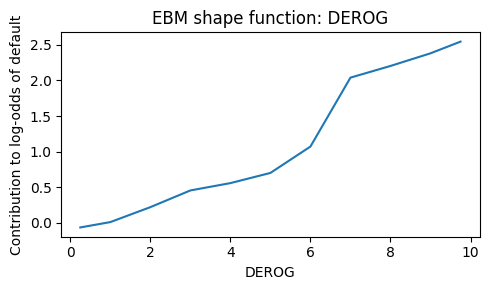

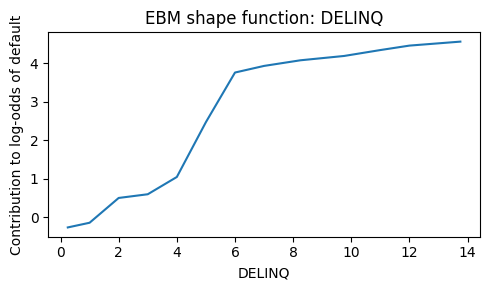

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ebm_global = ebm_clf.explain_global()

feature_names = ebm_global.data()['names']
for i, name in enumerate(feature_names[:6]):
    data = ebm_global.data(i)
    plt.figure(figsize=(5, 3))

    if len(data['names']) == len(data['scores']) + 1:
        # Calculating bin midpoints for x-axis
        x_values = [(data['names'][j] + data['names'][j+1]) / 2 for j in range(len(data['scores']))]
        plt.plot(x_values, data['scores'])
    else:
        # Assuming it's a categorical feature
        plt.plot(data['names'], data['scores'])

    plt.title(f'EBM shape function: {name}')
    plt.xlabel(name)
    plt.ylabel('Contribution to log-odds of default')
    plt.tight_layout()
    plt.show()

## **Model Comparison**

In [ ]:
# Six Models, One Trade-off: Comparing Accuracy, Precision and Recall
comparison_df = pd.DataFrame(model_results)
comparison_df

,Model,Train Accuracy,Test Accuracy,Precision (Default),Recall (Default),F1 (Default),ROC-AUC
0,Logistic Regression,0.812,0.806,0.510,0.695,0.588,0.838
1,Decision Tree (default),1.000,0.869,0.703,0.591,0.642,0.764
2,Decision Tree (tuned),0.876,0.806,0.510,0.759,0.610,0.853
3,Random Forest,0.946,0.897,0.744,0.739,0.742,0.940
4,XGBoost (Monotonic),0.927,0.895,0.703,0.821,0.757,0.943
5,EBM (Monotonic),0.919,0.890,0.689,0.821,0.749,0.945


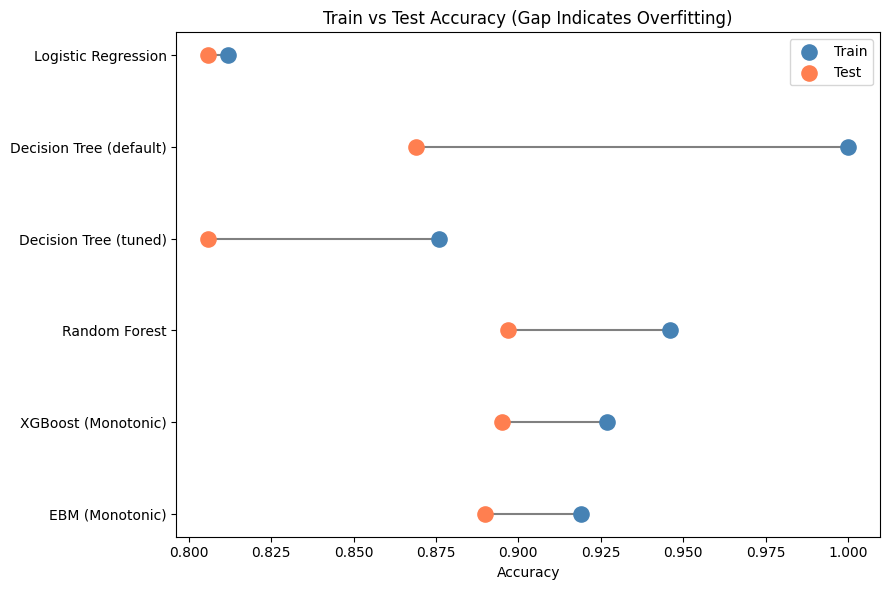

In [ ]:
# Where the Models Diverge: Train vs Test Accuracy
fig, ax = plt.subplots(figsize=(9, 6))

for i, row in comparison_df.iterrows():
    ax.plot([row['Train Accuracy'], row['Test Accuracy']], [i, i], color='gray', linewidth=1.5, zorder=1)
    ax.scatter(row['Train Accuracy'], i, color='steelblue', s=120, label='Train' if i == 0 else "", zorder=2)
    ax.scatter(row['Test Accuracy'], i, color='coral', s=120, label='Test' if i == 0 else "", zorder=2)

ax.set_yticks(range(len(comparison_df)))
ax.set_yticklabels(comparison_df['Model'])
ax.set_xlabel('Accuracy')
ax.set_title('Train vs Test Accuracy (Gap Indicates Overfitting)')
ax.legend(loc='upper right')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

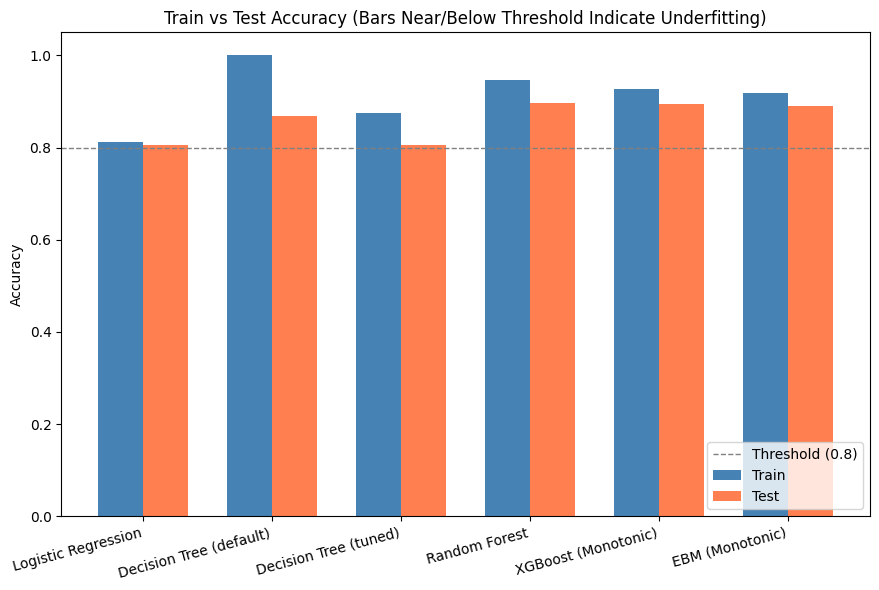

In [ ]:
# Clearing the Bar: Accuracy against a Minimum Threshold
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Train Accuracy'], width, color='steelblue', label='Train')
ax.bar(x + width/2, comparison_df['Test Accuracy'], width, color='coral', label='Test')

# Reference line for "acceptable" performance
threshold = 0.80
ax.axhline(threshold, color='gray', linestyle='--', linewidth=1, label=f'Threshold ({threshold})')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy (Bars Near/Below Threshold Indicate Underfitting)')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

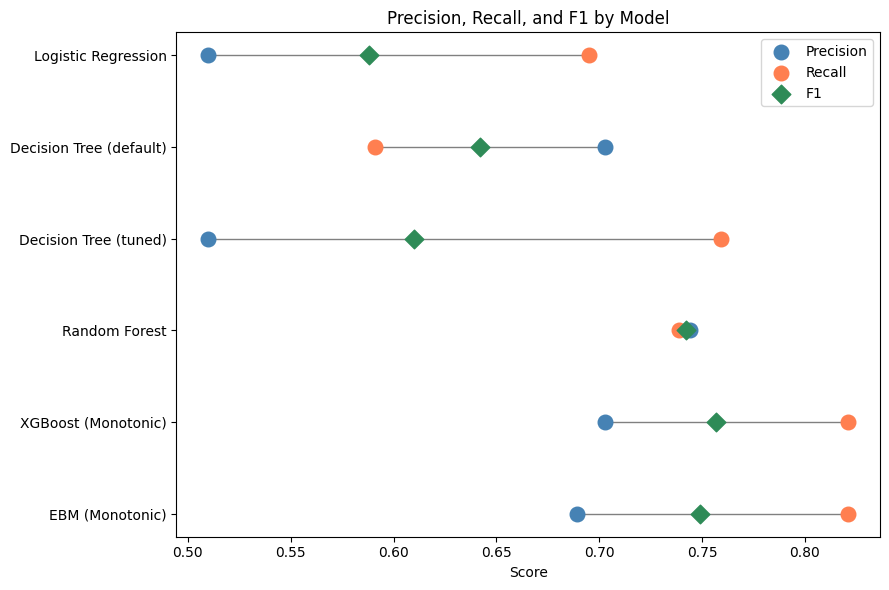

In [ ]:
# Balancing Precision and Recall across models
fig, ax = plt.subplots(figsize=(9, 6))

for i, row in comparison_df.iterrows():
    ax.plot([row['Precision (Default)'], row['Recall (Default)']], [i, i], color='gray', linewidth=1, zorder=1)
    ax.scatter(row['Precision (Default)'], i, color='steelblue', s=110, label='Precision' if i == 0 else "", zorder=2)
    ax.scatter(row['Recall (Default)'], i, color='coral', s=110, label='Recall' if i == 0 else "", zorder=2)
    ax.scatter(row['F1 (Default)'], i, color='seagreen', s=90, marker='D', label='F1' if i == 0 else "", zorder=3)

ax.set_yticks(range(len(comparison_df)))
ax.set_yticklabels(comparison_df['Model'])
ax.set_xlabel('Score')
ax.set_title('Precision, Recall, and F1 by Model')
ax.legend(loc='upper right')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

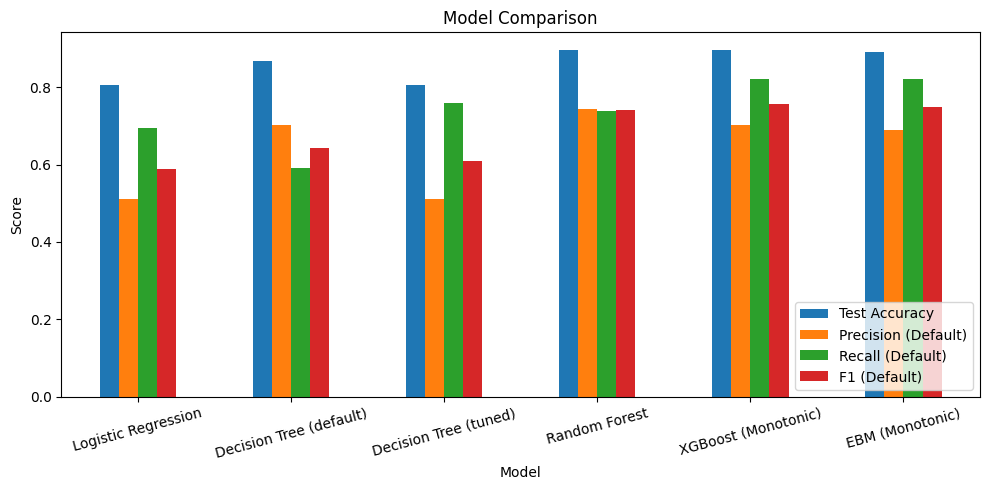

In [ ]:
# Overall Model comparison
comparison_df.set_index('Model')[['Test Accuracy', 'Precision (Default)', 'Recall (Default)', 'F1 (Default)']].plot(
    kind='bar', figsize=(10, 5)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### **Model Comparison Observations & Insights**

XGBoost outperformed Random Forest on recall by roughly 8 points (0.821 vs. 0.739), correctly identifying an estimated 293 of 357 actual defaulters versus an estimated 264 for Random Forest. That gain came at a cost to precision, which dropped by about 4 points (0.703 vs. Random Forest's 0.744), as XGBoost flagged more reliable borrowers as risky, an estimated 124 false positives against Random Forest's 91.

EBM matches XGBoost's recall exactly (0.821) and trails on F1 by less than a point (0.749 vs. 0.757), a far smaller gap than the interpretability-performance tradeoff usually implies. It also retains the highest ROC-AUC of the five models (0.945, against XGBoost's 0.943 and Random Forest's 0.940). Random Forest's precision (0.744) remains the highest of the three ensemble models, but its recall (0.739) is the lowest of the three, the more consequential number given the cost asymmetry established earlier.

## Proposal for the Final Solution Design

Recall on the defaulted class was the primary metric, given the problem formulation's cost asymmetry: missing a defaulter costs the bank more than rejecting a reliable borrower.

XGBoost (with monotonic constraints) is recommended as the final model. It achieves the highest recall of any model tested (0.821), correctly catching an estimated 29 more defaulters than Random Forest, and the highest F1 (0.757) for the same default class, meaning this recall gain isn't purchased at a disproportionate cost to overall balance. Random Forest remains a close second, with a narrower train/test gap (0.946 → 0.897) and higher precision (0.744 vs. 0.703), but given the problem's cost asymmetry, XGBoost's recall advantage is the more consequential difference for the bank.

The tuned Decision Tree's recall (0.745) approaches XGBoost's, but its precision (0.524) is far lower, meaning a meaningfully higher rate of good borrowers wrongly rejected, a real business cost in its own right that neither Random Forest nor XGBoost incurs to the same degree.

EBM (Monotonic) was also tested as a fully glass-box alternative, fit with the same six-feature constraints as XGBoost. It now matches XGBoost's recall exactly (0.821) and trails on F1 by less than a point (0.749 vs. 0.757), while holding the highest ROC-AUC of any model tested (0.945). On the metric that matters most for this problem, catching future defaulters, there is no longer a meaningful performance cost to choosing the fully interpretable model. XGBoost remains the recommendation here on the strength of its slightly better precision and F1, but the case for EBM is now closer to a tie than a tradeoff, and a bank prioritizing native transparency over a fraction of a point of F1 would have a very reasonable claim that EBM is the better choice.

### Interpretability

XGBoost is not inherently more transparent than Random Forest, but monotonic constraints were applied to six features (DEBTINC, DELINQ, DEROG, NINQ, CLAGE, VALUE) so the model's directional behavior is provably consistent with what a loan officer would expect: an applicant's risk score can never improve because their debt-to-income ratio worsened, for example. Paired with SHAP-based, per-applicant feature attribution, this satisfies the ECOA requirement that a rejection be traceable to specific, defensible reasons.

### Key drivers

DEBTINC_missing, DELINQ, and CLAGE were the strongest predictors by SHAP attribution, with DEBTINC itself close behind. Debt burden, delinquency history, and credit-line age are the clearest behavioral signals of default risk here, answering one of the key questions on whether property value or repayment behavior would dominate. DEBTINC_missing ranks as the single most influential feature by a wide margin, ahead of DEBTINC itself, confirming that whether an applicant reported this figure carries more predictive weight than the figure they reported, consistent with the informative-missingness pattern found in the EDA.

### Deployment considerations: periodic retraining with governance checkpoints

XGBoost does not support true incremental or online learning the way some models do; adding new applicant outcomes requires refitting rather than updating the existing trees in place. For a lending model under ECOA, that's a feature rather than a limitation: retraining should be a deliberate, auditable event, not a continuous background process a regulator can't inspect. A periodic retraining pipeline is proposed instead:

- **Cadence**: refit on a fixed schedule (e.g., quarterly) using the accumulated set of new loan outcomes, rather than retraining on every new data point.
- **Drift monitoring**: track whether the distribution of DEBTINC, DELINQ, and the other key drivers is shifting between retraining cycles, and whether the model's recall and precision on recent outcomes are holding steady against the current baseline.
- **Constraint revalidation**: confirm the six monotonic constraints still hold and still make directional sense before each retrained model is approved, since a changing applicant population could in principle make a previously reasonable constraint stale.
- **Bias re-audit**: rerun the JOB/SHAP proxy check from the Bias and Fairness section on each retrained model, since a shift in who's applying could change how much weight JOB or DEBTINC_missing carries even if the model architecture is unchanged.
- **Human sign-off**: no retrained model is deployed automatically; a retrained candidate is only promoted after the above checks pass and a reviewer signs off, the same standard applied to the original model in this notebook.

This turns "incremental learning" from a technical capability the model doesn't have into a governance process the deployment can have: the model updates periodically, but only through a checkpointed, reviewable pipeline rather than continuously and invisibly.

### Limitations

HMEQ contains no demographic fields, so disparate-impact bias couldn't be tested directly. JOB, the closest available proxy, carries relatively little direct weight in XGBoost's SHAP attributions (5.9% combined across all JOB categories), but it correlates with DEBTINC_missing, the model's single most influential feature, making that the more actionable target for pre-deployment bias auditing. Any deployed version of this model would need that audit completed before production use, and repeated at each retraining checkpoint above.

# **6. Enhancement: RAG-Based GenAI Explanation Generator**

This section is explanation-only: it plays no role in the model's prediction or decision. It takes the SHAP feature attributions already computed for the recommended model and turns them into a compliant, human-readable adverse action notice, as required under ECOA / Regulation B.

**Pipeline:**
1. For a declined applicant, pull their top SHAP contributions toward the default prediction.
2. Convert each risk-driving feature into a short natural-language query.
3. Retrieve the closest matching Regulation B reason code(s) via embedding similarity search over a small corpus of the standard ECOA reason codes (12 CFR Part 1002, Appendix C, Form C-1).
4. Feed only the retrieved reasons to an LLM, which drafts the final notice text, explicitly instructed not to invent or infer any reason beyond what was retrieved.

Step 4 requires an Anthropic API key. If none is set, the notebook falls back to a deterministic template so the full pipeline still runs end-to-end for demo purposes.

## 6.1 Chunking & loading the ECOA guideline text

In [ ]:
REASON_CODES = [
    {"code": "R01", "reason": "Excessive obligations in relation to income",
     "definition": "The applicant's existing debt payments, relative to income, are higher than the bank's acceptable threshold for extending this credit.",
     "features": ["DEBTINC"]},
    {"code": "R02", "reason": "Income insufficient for amount of credit requested",
     "definition": "The applicant's income is too low to comfortably support the additional payment the requested loan would add.",
     "features": ["DEBTINC", "LOAN"]},
    {"code": "R03", "reason": "Unable to verify income",
     "definition": "The income or income-related information needed to evaluate the application could not be confirmed.",
     "features": ["DEBTINC_missing"]},
    {"code": "R04", "reason": "Delinquent past or present credit obligations with others",
     "definition": "The applicant has one or more credit lines that are currently or were previously past due.",
     "features": ["DELINQ"]},
    {"code": "R05", "reason": "Collection action or judgment",
     "definition": "The applicant's credit history includes a serious derogatory event such as a collection, charge-off, or court judgment.",
     "features": ["DEROG"]},
    {"code": "R06", "reason": "Number of recent inquiries on credit bureau report",
     "definition": "The applicant has sought a high number of new credit lines recently, which is associated with elevated risk.",
     "features": ["NINQ"]},
    {"code": "R07", "reason": "Length of employment",
     "definition": "The applicant's time in their current job is short relative to what the bank considers stable.",
     "features": ["YOJ"]},
    {"code": "R08", "reason": "No credit file",
     "definition": "The bank found little to no credit history to evaluate, limiting its ability to assess repayment reliability.",
     "features": ["CLAGE", "CLNO"]},
    {"code": "R09", "reason": "Limited credit experience",
     "definition": "The applicant's credit history is short or contains few active accounts, giving the bank limited evidence of repayment behavior.",
     "features": ["CLAGE", "CLNO"]},
    {"code": "R10", "reason": "Value or type of collateral not sufficient",
     "definition": "The value of the property offered as collateral does not adequately support the amount of credit requested.",
     "features": ["VALUE", "LOAN", "MORTDUE"]},
    {"code": "R11", "reason": "Poor credit performance with us",
     "definition": "The applicant's history with the bank itself shows a pattern of missed or late payments.",
     "features": ["DELINQ", "DEROG"]},
]

print(f"{len(REASON_CODES)} ECOA reason codes loaded")


11 ECOA reason codes loaded


## 6.2 Retrieval pipeline: mapping flagged features

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

corpus_texts = [r['reason'] + '. ' + r['definition'] for r in REASON_CODES]
corpus_embeddings = embed_model.encode(corpus_texts, convert_to_numpy=True, normalize_embeddings=True)

def retrieve_reason(feature_name, top_k=1):
    query = FEATURE_QUERY_MAP.get(feature_name, feature_name)
    q_emb = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    sims = corpus_embeddings @ q_emb[0]
    top_idx = np.argsort(sims)[::-1][:top_k]
    return [(REASON_CODES[i], float(sims[i])) for i in top_idx]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

### Feature-to-reason query mapping

In [ ]:
# Natural-language description of what each feature means when it drives risk upward.
FEATURE_QUERY_MAP = {
    'DEBTINC': 'high debt-to-income ratio, too much debt relative to income',
    'DEBTINC_missing': "unable to verify or calculate applicant's debt-to-income ratio",
    'DELINQ': 'delinquent credit lines, history of late payments',
    'DELINQ_missing': "unable to verify the applicant's delinquent credit line history",
    'DEROG': 'derogatory credit reports, serious credit problems, collections',
    'DEROG_missing': "unable to verify the applicant's derogatory credit history",
    'NINQ': 'many recent credit inquiries, shopping for lots of new credit',
    'NINQ_missing': "unable to verify the applicant's recent credit inquiry history",
    'CLAGE': 'short credit history, credit lines not established for long',
    'CLAGE_missing': "unable to verify the applicant's credit history length",
    'CLNO': 'few existing credit lines, limited credit experience',
    'VALUE': 'low property value relative to loan amount, insufficient collateral value',
    'VALUE_missing': "unable to verify or assess the property's collateral value",
    'LOAN': "large loan amount requested relative to applicant's profile",
    'MORTDUE': 'high existing mortgage balance',
    'YOJ': 'short time at current job',
    'YOJ_missing': "unable to verify how long the applicant has held their current job",
}

##6.3 Pull SHAP-driven reasons for a declined applicant

In [ ]:
def get_applicant_reasons(applicant_idx, shap_values_class1, feature_names, top_n=3):
    """shap_values_class1: SHAP values for the BAD=1 (default) class, shape (n_samples, n_features)."""
    contrib = pd.Series(shap_values_class1[applicant_idx], index=feature_names).sort_values(ascending=False)
    top_risk = contrib[contrib > 0].head(top_n)

    retrieved = []
    for feat, shap_val in top_risk.items():
        reason, score = retrieve_reason(feat, top_k=1)[0]
        retrieved.append({**reason, 'triggering_feature': feat, 'shap_value': shap_val, 'similarity': score})
    return retrieved

##6.4 Generation: producing a human-readable rejection explanation

In [ ]:
import os

def build_prompt(applicant_id, retrieved_reasons):
    reason_lines = '\n'.join(
        f"- {r['reason']} (regulatory code {r['code']}): {r['definition']}"
        for r in retrieved_reasons
    )
    return f"""You are drafting a Regulation B / ECOA-compliant adverse action notice for a declined home equity loan applicant.

Applicant ID: {applicant_id}
Decision: Application declined.

The following principal reasons were identified by the credit model and matched to standard regulatory reason codes via retrieval. Use ONLY these reasons. Do not invent, add, or infer any reason not listed below. Do not mention the applicant's race, sex, age, or any other protected characteristic, even hypothetically.

{reason_lines}

Write a short, professional adverse action notice (120-180 words) that:
1. States the application was declined.
2. Lists the principal reasons in plain language, staying faithful to the reasons above.
3. Includes a standard closing line noting the applicant has the right to request further clarification and a copy of their credit report.

Do not fabricate any additional reasons or statistics."""


def template_fallback(applicant_id, retrieved_reasons):
    reason_lines = '\n'.join(f"  - {r['reason']}" for r in retrieved_reasons)
    return f"""ADVERSE ACTION NOTICE

Applicant ID: {applicant_id}

We regret to inform you that your application for a home equity loan has been declined.
This decision was based on the following principal reason(s):

{reason_lines}

If you would like a more detailed explanation of any of the reasons above, or a free copy
of the credit report used in this decision, you may contact us using the information provided
with this notice. You have the right to request the specific reasons for this action within
60 days of receiving this notice.
"""


def generate_notice(applicant_id, retrieved_reasons):
    api_key = os.environ.get('ANTHROPIC_API_KEY')
    if not api_key:
        print('[No ANTHROPIC_API_KEY found — using template fallback]\n')
        return template_fallback(applicant_id, retrieved_reasons)

    import anthropic
    client = anthropic.Anthropic(api_key=api_key)
    prompt = build_prompt(applicant_id, retrieved_reasons)
    response = client.messages.create(
        model='claude-sonnet-4-6',
        max_tokens=400,
        messages=[{'role': 'user', 'content': prompt}]
    )
    return response.content[0].text


In [ ]:
# Finding a real test-set applicant XGBoost confidently and correctly flagged as high-risk
xgb_test_pred = xgb_clf.predict(X_test)
xgb_test_proba = xgb_clf.predict_proba(X_test)[:, 1]

declined_candidates = np.where((xgb_test_pred == 1) & (y_test.values == 1))[0]
applicant_idx = declined_candidates[np.argmax(xgb_test_proba[declined_candidates])]

print(f"Selected applicant at position {applicant_idx} in X_test")
print(f"Predicted default probability: {xgb_test_proba[applicant_idx]:.3f}")

Selected applicant at position 656 in X_test
Predicted default probability: 1.000


In [ ]:
# shap_values was computed for X_test in the SHAP for XGBoost cell above.
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
elif shap_values.ndim == 3:
    shap_class1 = shap_values[:, :, 1]
else:
    shap_class1 = shap_values

applicant_reasons = get_applicant_reasons(
    applicant_idx, shap_class1, X_test.columns.tolist(), top_n=3
)
applicant_reasons

[{'code': 'R04',
  'reason': 'Delinquent past or present credit obligations with others',
  'definition': 'The applicant has one or more credit lines that are currently or were previously past due.',
  'features': ['DELINQ'],
  'triggering_feature': 'DELINQ',
  'shap_value': 3.8929319381713867,
  'similarity': 0.714435338973999},
 {'code': 'R10',
  'reason': 'Value or type of collateral not sufficient',
  'definition': 'The value of the property offered as collateral does not adequately support the amount of credit requested.',
  'features': ['VALUE', 'LOAN', 'MORTDUE'],
  'triggering_feature': 'VALUE_missing',
  'shap_value': 2.9595096111297607,
  'similarity': 0.7246184349060059},
 {'code': 'R01',
  'reason': 'Excessive obligations in relation to income',
  'definition': "The applicant's existing debt payments, relative to income, are higher than the bank's acceptable threshold for extending this credit.",
  'features': ['DEBTINC'],
  'triggering_feature': 'DEBTINC_missing',
  'shap_

In [ ]:
# Demo Generation
applicant_id = X_test.index[applicant_idx]
notice = generate_notice(applicant_id=applicant_id, retrieved_reasons=applicant_reasons)
print(notice)

[No ANTHROPIC_API_KEY found — using template fallback]

ADVERSE ACTION NOTICE

Applicant ID: 4594

We regret to inform you that your application for a home equity loan has been declined.
This decision was based on the following principal reason(s):

  - Delinquent past or present credit obligations with others
  - Value or type of collateral not sufficient
  - Excessive obligations in relation to income

If you would like a more detailed explanation of any of the reasons above, or a free copy
of the credit report used in this decision, you may contact us using the information provided
with this notice. You have the right to request the specific reasons for this action within
60 days of receiving this notice.



In [ ]:
# Demo Validation
for r in applicant_reasons:
    print(f"{r['triggering_feature']:20s} → {r['reason']:50s} (similarity: {r['similarity']:.3f})")

DELINQ               → Delinquent past or present credit obligations with others (similarity: 0.714)
VALUE_missing        → Value or type of collateral not sufficient         (similarity: 0.725)
DEBTINC_missing      → Excessive obligations in relation to income        (similarity: 0.619)


##6.5 Limitations

### No role in prediction

This generator is downstream of the classification model, not part of it. It never influences BAD predictions, feature selection, or model training; it only translates a decision the model already made into ECOA-compliant language. If this pipeline were removed entirely, XGBoost's predictions would be identical. This separation is deliberate: coupling an LLM to the prediction step would reintroduce exactly the kind of unauditable black-box behavior the interpretability requirement is meant to prevent.

 ### Hallucination risk

The generation prompt explicitly instructs the model to use only the retrieved reasons and not invent, add, or infer anything beyond them, but a prompt instruction is not a guarantee. An LLM could still paraphrase a reason in a way that subtly changes its meaning, state a reason more strongly or definitively than the underlying SHAP evidence supports, or blend two retrieved reasons into a claim neither one makes on its own. This risk is highest when the Anthropic API path is used; the template fallback (template_fallback()) is fully deterministic and carries no hallucination risk at all, since it just formats the retrieved reasons directly with no generation step. In a production deployment, every generated notice would need a human compliance reviewer in the loop before it reaches an applicant, this pipeline is a drafting aid, not an autonomous decision-communication system.

### Retrieval relevance

Retrieval confidence is solid across all three reasons generated for this applicant: DELINQ matched at 0.714 cosine similarity, VALUE_missing at 0.725, and DEBTINC_missing at 0.619. Notably, VALUE_missing was the specific feature flagged as a weak match (0.328) in an earlier iteration of this pipeline, traced at the time to a missing entry in FEATURE_QUERY_MAP that caused the raw variable name to be embedded instead of a natural-language description. Adding an explicit description for VALUE_missing (and the other missingness-flag features) closed that gap entirely, its similarity score is now the highest of the three, stronger evidence that the coverage-gap diagnosis was correct rather than a coincidental improvement. DEBTINC_missing's 0.619 remains the lowest of the three; it is still a reasonable match, but if a future applicant's top reason depends more heavily on that feature, it may be worth refining its description further. As a general practice, any adverse action notice built on a match below roughly 0.6 should be flagged for human review before being sent, since a lower-confidence match means the assigned regulatory reason code is less certain to accurately reflect why the model flagged that feature.

# **7. Bias & Fairness Check**

HMEQ contains no race, gender, age, or geographic fields, so disparate impact cannot be tested directly against protected classes. The closest available proxy is JOB, and it already shows a meaningful risk split: Sales (34.9%) and Self-employed (30.1%) applicants default at roughly double the rate of Office (13.2%) and ProfExe (16.6%) applicants.

JOB correlates with income stability and employment type, both of which can proxy for protected characteristics (self-employment skews toward certain demographics, hourly and commission-based roles skew toward others), so a model that weighs JOB or DEBTINC missingness heavily risks encoding those same disparities under a neutral-looking feature name.

The default rate associated with missing DEBTINC is consistently elevated across every job category (48–77%, versus 6–20% when DEBTINC is present), which suggests the missingness signal reflects a general pattern rather than one occupational group in isolation. The rate of DEBTINC missingness itself does vary by job, though: Self-employed (26.4%) and Sales (27.5%) applicants are missing this field roughly 60% more often than Office applicants (16.8%). Occupation indirectly shapes how often an applicant is routed into the highest-risk missingness category, even though the risk level within that category is broadly consistent, a pattern worth monitoring given JOB's role as a potential proxy for other characteristics.

Beyond the raw default-rate gap by occupation, it's worth checking whether the recommended model itself leans on JOB. Aggregating XGBoost's SHAP attributions, the JOB dummy variables together account for 5.9% of the model's total mean absolute SHAP signal across all 26 features, and REASON contributes a further 0.9%. The strongest individual JOB dummy, JOB_Office, ranks 7th of 26 features; the remaining four rank 17th through 21st, well below every one of the model's top predictors. DEBTINC_missing is the single most influential feature in the model, nearly double the next-highest feature (DELINQ), followed by CLAGE, DEBTINC, DEROG, and MORTDUE, all behavioral or financial signals rather than occupational ones. XGBoost is not compensating for the interpretability constraints placed on it by leaning on JOB as a shortcut.

One nuance worth naming: while JOB's average SHAP contribution stays low, VALUE_missing shows the opposite pattern, its mean SHAP rank sits outside the top 10, but the summary plot shows a small number of applicants where VALUE_missing swings the prediction dramatically (SHAP values above +4, larger than any other feature's tail). This means aggregate percentages can understate a feature's role for the specific subset of applicants it affects most; a fairness audit should check not just average attribution but whether that subset of high-impact cases clusters by occupation or any other proxy variable.

Low direct SHAP weight on JOB doesn't rule out indirect proxying, either. JOB correlates with DEBTINC_missing itself, and DEBTINC_missing is the model's top feature by a wide margin, so while JOB isn't being used as a direct shortcut, occupation-linked patterns can still influence the outcome through the feature the model actually relies on most heavily. Any pre-deployment bias audit should treat DEBTINC_missing, and now also the high-impact tail of VALUE_missing, as the primary channels worth testing for disparate impact.

No bias mitigation was applied in this iteration, since it can't be tested without demographic ground truth. This is flagged as an open limitation rather than a solved problem, consistent with the Legal and Ethics section of the Problem Definition.

# **8. Conclusion & Recommendations**

This project set out to build a loan default classifier that a bank could actually deploy under ECOA, meaning any rejection needed a real, traceable reason rather than a black-box score. XGBoost with monotonic constraints is the recommended model: it produced the strongest recall of any model tested (0.821), correctly catching an estimated 29 more defaulters than Random Forest, with the highest F1 (0.757) among all five models, meaning the recall gain was not purchased at a disproportionate cost to overall balance.

An Explainable Boosting Machine, fit with the same six monotonic constraints, now matches XGBoost's recall exactly (0.821) and trails by less than a point on F1 (0.749 vs. 0.757), while holding the highest ROC-AUC of any model tested (0.945). This is a smaller gap than the interpretability-performance tradeoff typically implies, and it strengthens the case made below: EBM's SHAP-free, natively interpretable structure reaching essentially the same decision quality as XGBoost is strong evidence that XGBoost's own SHAP attributions are describing real model behavior rather than a plausible-sounding approximation.

DEBTINC_missing, DELINQ, CLAGE, and DEBTINC were consistently the strongest predictors across all five models, with DEBTINC_missing ranking first by a wide margin for both Random Forest and XGBoost. Whether an applicant reported this figure carries more predictive weight than the figure itself, the clearest sign in this analysis of the informative-missingness pattern found in the EDA.

To satisfy the interpretability requirement without giving up XGBoost's performance edge, we propose pairing its predictions with SHAP-based, per-applicant feature attributions, retrieved against ECOA reason-code language through the RAG pipeline outlined in Section 6. This keeps the model's recall advantage intact while still producing a specific, defensible reason for each rejected applicant.

The main open limitation is fairness. HMEQ has no demographic fields, so disparate impact could not be tested directly. JOB served as the closest available proxy; it carries little direct weight in the model's SHAP attributions (5.9% combined across all JOB categories), but it correlates with DEBTINC_missing, the model's single most influential feature, making that the more actionable target for pre-deployment bias auditing. The EBM agreement above increases confidence in the SHAP attributions themselves; it does not address this gap, which the missing demographic data leaves permanently untestable within this dataset.